Time Series Forecasting
ARIMA

In [ ]:
!pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import math
%matplotlib inline

from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import StandardScaler


In [ ]:
import warnings
warnings.filterwarnings('ignore')

Helper Functions


In [ ]:
# Fuction to extract data from a dataframe given the name of the data_field name and the corrresponding value
def get_store_df(data, data_field, field_value):
    return data[data[data_field] == field_value].copy()

In [ ]:
def plot_graph(dbf,plt_ht=3, plt_wt=2, hd_space=0.5, fig_size=(15,7)):
  fig, axes= plt.subplots(plt_ht,plt_wt, figsize=fig_size)
  plt.subplots_adjust(hspace = hd_space)

  col_names=list(dbf.columns)
  for i, ele in enumerate(col_names):
    if dbf[ele].dtypes=='float64' or dbf[ele].dtypes=='int64':
      if i < len(col_names)-1:
        plt.subplot(plt_ht, plt_wt, i+1)
        sns.boxplot(x=dbf[ele])
        plt.xlabel(ele)
        plt.xticks(rotation=45)

In [ ]:
#Function to examine dataframe for illigal entries
# input is a dataframe and a list of possible invalid entries
# to look for
# Returns a dataframe of illigal entries if found
def get_invalid_entry(dbf,invalid_data=['?','@',"#"]):
  bad_df=pd.DataFrame(columns=['col_name','bad_entry','Total']).dropna()
  col_names=list(dbf.columns)
  inv_ent,inv_col,num=[],[],[]

  for j in invalid_data:
    for i,col in enumerate(col_names):
      x=dbf[(dbf[col]==j)].shape[0]
      if x> 0:
        inv_ent.append(j)
        inv_col.append(col)
        num.append(x)
    bad_df['col_name']=inv_col
    bad_df['bad_entry']=inv_ent
    bad_df['Total']=num
  if bad_df.shape[0]>2:
    print('Some invalid entries were found')
    ret_val=bad_df
  else:
    ret_val="No invalid/bad entry found"
  return(ret_val)

In [ ]:
def format_number(number):
  return("{:,}".format(number))

In [ ]:
# Plot the Effects of Temperature, CPI, Unemployment, and, Fuel_price on
# Weely_Sales:
def plot_features_effect(store_list):
  plt.subplots_adjust(wspace=0.2)
  font_axis, font_tick =25,25
  font_title = 35

  for i in store_list:
    fig,axes=plt.subplots(2, 2, figsize=(45, 15))
    plt.subplots_adjust(hspace=0.5)

    store_df=get_store_df(df,'Store',i)

    plt.subplot(2,2,1)
    sns.lineplot(x='Fuel_Price', y='Weekly_Sales',data=store_df,color='blue');
    plt.title(f"Store {i}:Effects of Fuel Price on weekly Sales",fontsize=font_title)
    plt.xlabel('Fuel Price',fontsize=font_axis)
    plt.ylabel('Weekly Sales',fontsize=font_axis)
    plt.xticks(fontsize=font_tick)
    plt.yticks(fontsize=font_tick)

    plt.subplot(2,2,2)
    sns.lineplot(x='CPI',y='Weekly_Sales',data=store_df,color="red");
    plt.title(f"Store {i}: Effects of CPI on weekly Sales",fontsize=font_title)
    plt.xlabel('CPI',fontsize=font_axis)
    plt.ylabel('Weekly Sales',fontsize=font_axis)
    plt.xticks(fontsize=font_tick)

    plt.subplot(2,2,3)
    sns.lineplot(x='Unemployment',y='Weekly_Sales',data=store_df,color="red");
    plt.title(f"Store {i}: Effects of Unemployment on weekly Sales",fontsize=font_title)
    plt.xlabel('Unemployment',fontsize=font_axis)
    plt.ylabel('Weekly Sales',fontsize=font_axis)
    plt.xticks(fontsize=font_tick)

    plt.subplot(2,2,4)
    sns.lineplot(x='Temperature',y='Weekly_Sales',data=store_df,color="red");
    plt.title(f"Store {i}: Effects of Temperature on weekly Sales",fontsize=font_title)
    plt.xlabel('Temperature',fontsize=font_axis)
    plt.ylabel('Weekly Sales',fontsize=font_axis)
    plt.xticks(fontsize=font_tick)
    plt.show()

### Step1 : Read Input data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Walmart DataSet.csv',
               index_col = 'Date', parse_dates=True)
df_saved=df.copy()
df2=df.copy()

In [ ]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-05-02,1,1643690.90,0,42.31,2.572,211.096358,8.106
2010-12-02,1,1641957.44,1,38.51,2.548,211.242170,8.106
2010-02-19,1,1611968.17,0,39.93,2.514,211.289143,8.106
2010-02-26,1,1409727.59,0,46.63,2.561,211.319643,8.106
2010-05-03,1,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df['Weekly_Sales'].min()

209986.25

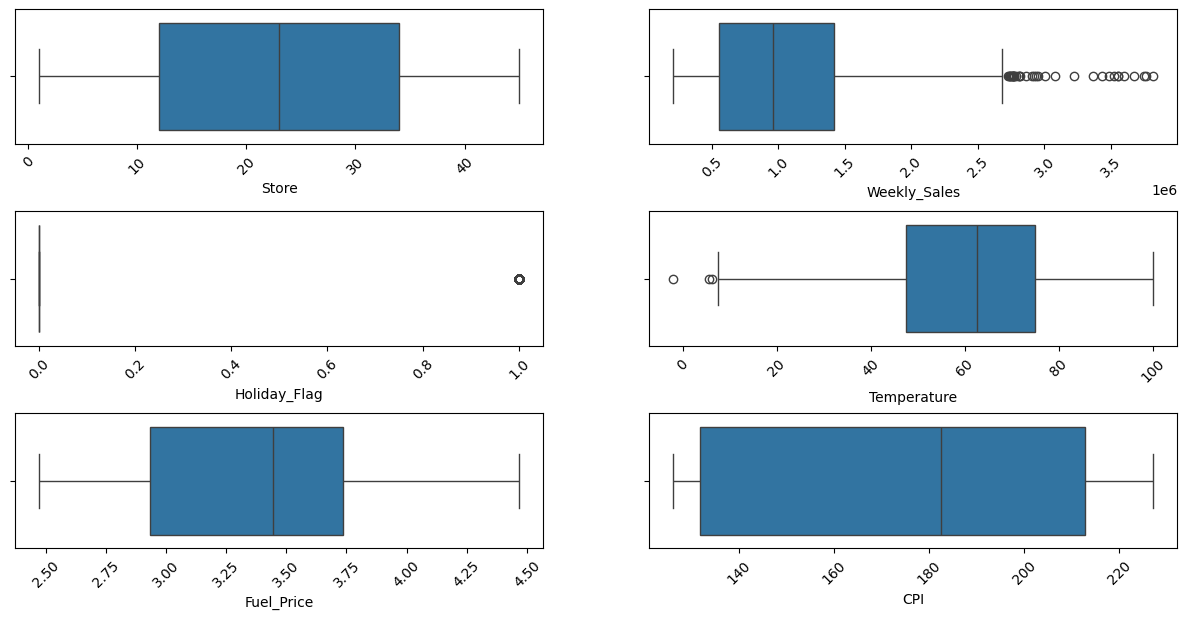

In [ ]:
plot_graph(df)

In [ ]:
import pandas as pd
xdf=df.groupby('Store')['Temperature','Weekly_Sales'].value_counts()
x_Index = xdf.index
x_store, x_temp, x_ant=[],[],[]
for i in x_Index:
  x_set=list(i)
  x_store.append(x_set[0])
  x_temp.append(x_set[1])
  x_ant.append(x_set[2])
xdf = pd.DataFrame(zip(x_store, x_temp, x_ant), columns=['Store', 'Temperature', 'Ant'])
xdf.head()

,Store,Temperature,Ant
0,1,35.40,1391013.96
1,1,36.39,1649614.93
2,1,67.61,1649604.63
3,1,69.87,1506126.06
4,1,69.86,1345454.00


In [ ]:
store_list=df['Store'].unique()
store_list

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

### Step2: Exploratory Data Analysis

In [ ]:
# Size of our data
df.shape

(6435, 7)

In [ ]:
# Number of Stores:
df.groupby(['Store'])['Store'].unique().shape[0]

45

In [ ]:
#List of stores
Store_list=list(set(df['Store']))
print(Store_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]


In [ ]:
#Data types
df.dtypes

Store             int64
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [ ]:
df.isnull().sum()

Store           0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [ ]:
# Check for Invalid Entry
get_invalid_entry(df,invalid_data=['?','@','#'])
#no invalid /bad entry found

'No invalid/bad entry found'

In [ ]:
# Check for duplicates
df.duplicated()

Date
2010-05-02    False
2010-12-02    False
2010-02-19    False
2010-02-26    False
2010-05-03    False
              ...  
2012-09-28    False
2012-05-10    False
2012-12-10    False
2012-10-19    False
2012-10-26    False
Length: 6435, dtype: bool

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


In [ ]:
df.corr()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


### Correlation of Target feature(Weekly_Sales) with The Independent Features:

In [ ]:
# It may be necessary to check the specific corrliniarity between the target variable
#(weekly_sales) and the other variables (the independent variables) for each store
store_corr=pd.DataFrame(index=['Store','Weekly_Sales','Holiday_Flag',
                               'Temperature','Fuel_Price','CPI','Unemployment'])
store_corr
for i in range(1,46):
  store_df=get_store_df(df,'Store',i)
  store_corr['Store_'+str(i)]=store_df.corr()['Weekly_Sales'].tolist()

In [ ]:
store_corr=store_corr.dropna()
store_corrT=store_corr.T
del store_corrT['Weekly_Sales']
store_corrT

,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store_1,0.194905,-0.222701,0.124592,0.225408,-0.097955
Store_2,0.177726,-0.297673,-0.196375,-0.062431,0.066325
Store_3,0.208556,-0.377524,0.140886,0.317250,-0.230413
Store_4,0.153388,-0.225583,0.211549,0.351157,-0.337015
Store_5,0.302525,-0.175517,0.167352,0.308261,-0.207043
Store_6,0.150424,-0.084863,-0.103356,-0.011357,0.044251
Store_7,0.248766,0.015077,0.110356,0.289044,-0.165382
Store_8,0.172383,-0.312324,0.029752,0.120255,-0.052580
Store_9,0.179264,-0.208343,0.205404,0.294805,-0.191534
Store_10,0.195119,-0.432569,-0.185058,-0.115374,0.131908


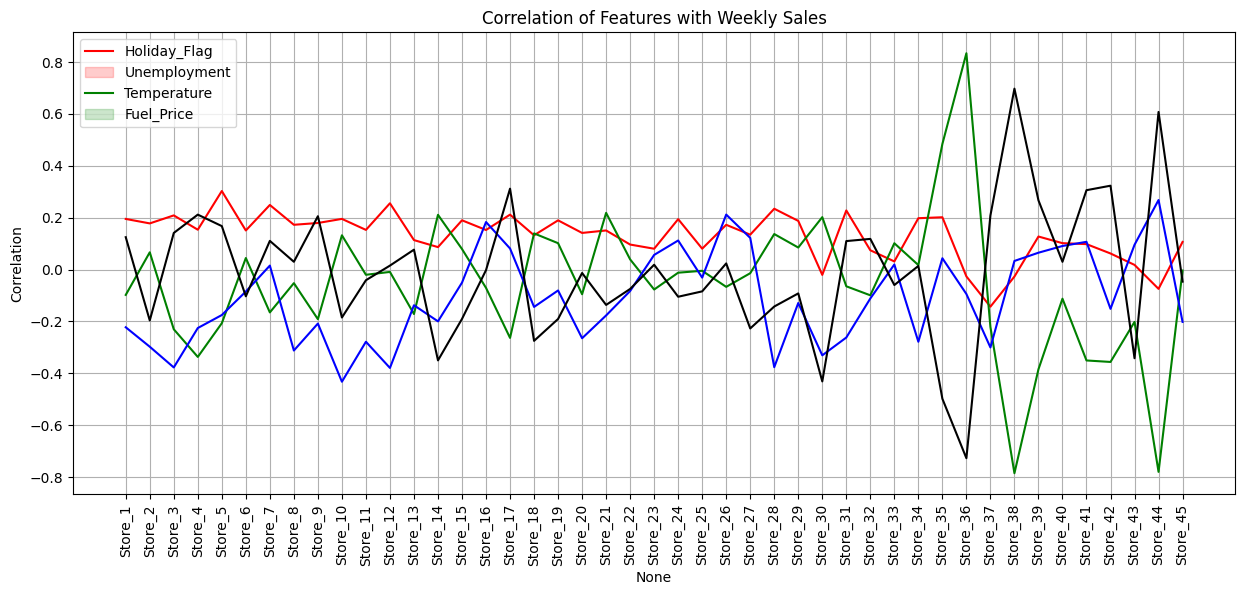

In [ ]:
# Examine the correlationship of independent features with weekly_Sales
fig,axes=plt.subplots(figsize=(15,6))
plt.xticks(rotation=90)
sns.lineplot(x=store_corrT.index,y=store_corrT.Holiday_Flag,color='red')
sns.lineplot(x=store_corrT.index,y=store_corrT.Unemployment,color='green')
sns.lineplot(x=store_corrT.index,y=store_corrT.Temperature,color='blue')
sns.lineplot(x=store_corrT.index,y=store_corrT.Fuel_Price,color='black')
plt.legend(['Holiday_Flag','Unemployment','Temperature','Fuel_Price'],loc='best')
plt.grid(True)
plt.ylabel("Correlation")
plt.title("Correlation of Features with Weekly Sales")
plt.show()

a. If the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?
Ans.  negative correlations (neg). The stores with the highest negative correlation values are:

Store_38: -0.785290
Store_44: -0.780076
Store_39: -0.384681
Store_42: -0.356355
Store_41: -0.350630
These stores are the ones suffering the most when unemployment increases.

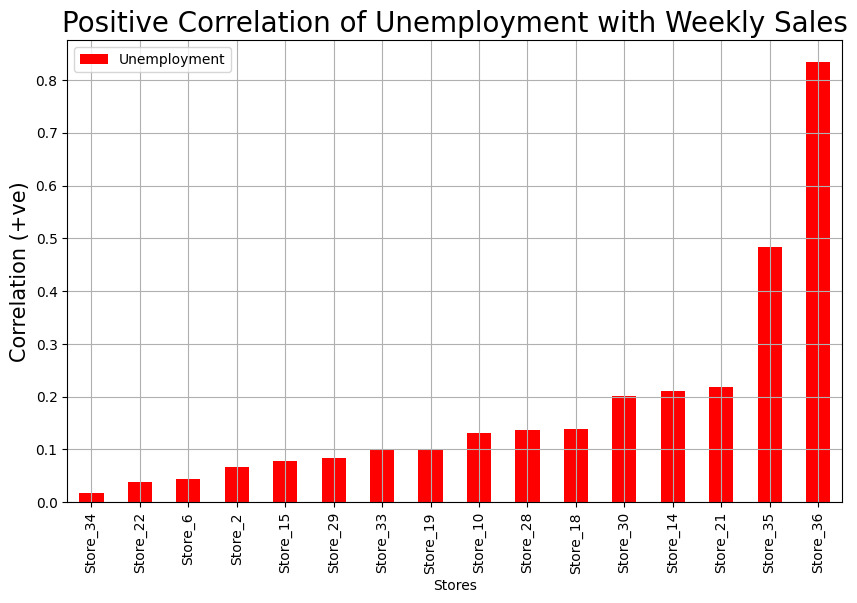

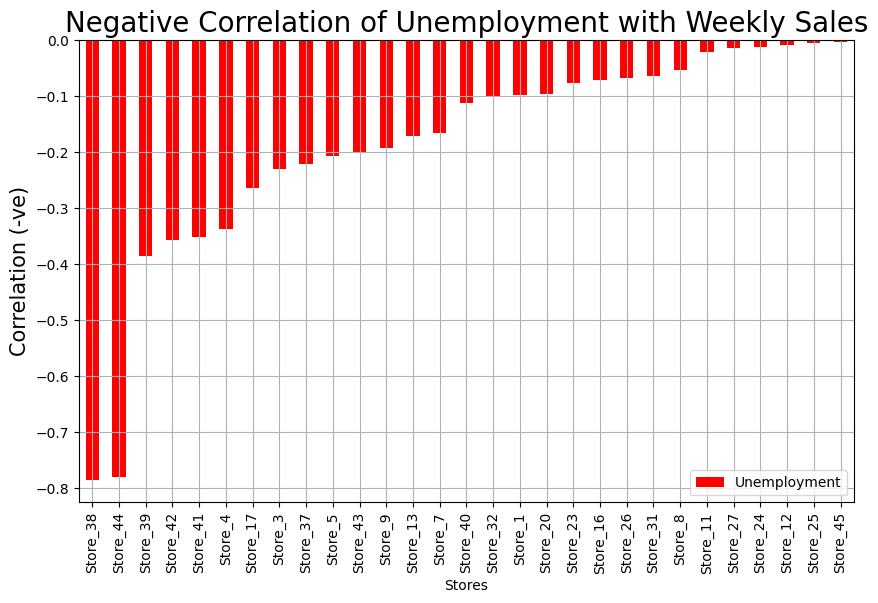

In [ ]:
# Positive Unemployment Correlation
pos_U_corr=store_corrT[store_corrT["Unemployment"]>0].sort_values(by='Unemployment')
pos_U_corr.plot(kind='bar', y='Unemployment', figsize=(10, 6), color='red')
plt.xlabel('Stores')
plt.ylabel("Correlation (+ve)", fontsize=15)
plt.title("Positive Correlation of Unemployment with Weekly Sales", fontsize=20)
plt.grid(True)

# Negative Unemployment Correlation
neg_U_corr=store_corrT[store_corrT["Unemployment"]<0].sort_values(by='Unemployment')
neg_U_corr.plot(kind='bar', y='Unemployment', figsize=(10, 6), color='red')
plt.xlabel('Stores')
plt.ylabel("Correlation (-ve)", fontsize=15)
plt.title("Negative Correlation of Unemployment with Weekly Sales", fontsize=20)
plt.grid(True)

In [ ]:
Unemployment_1=pd.DataFrame(zip(pos_U_corr.index,pos_U_corr.Unemployment),
                            columns=['Stores(pos)','Corr(pos)'])
Unemployment_2=pd.DataFrame(zip(neg_U_corr.index,neg_U_corr.Unemployment),
                            columns=['Stores(neg)','Corr(neg)'])
Unemployment=pd.concat([Unemployment_2,Unemployment_1],axis=1,
                       join="outer",ignore_index=True)
Unemployment.columns=['Stores(neg)','Corr(neg)','Stores(pos)','Corr(pos)']
Unemployment

,Stores(neg),Corr(neg),Stores(pos),Corr(pos)
0,Store_38,-0.785290,Store_34,0.017010
1,Store_44,-0.780076,Store_22,0.039043
2,Store_39,-0.384681,Store_6,0.044251
3,Store_42,-0.356355,Store_2,0.066325
4,Store_41,-0.350630,Store_15,0.078905
5,Store_4,-0.337015,Store_29,0.084682
6,Store_17,-0.263600,Store_33,0.101175
7,Store_3,-0.230413,Store_19,0.101464
8,Store_37,-0.221287,Store_10,0.131908
9,Store_5,-0.207043,Store_28,0.136671


 negative correlations (neg). The stores with the highest negative correlation values are:

Store_38: -0.785290
Store_44: -0.780076
Store_39: -0.384681
Store_42: -0.356355
Store_41: -0.350630
These stores are the ones suffering the most when unemployment increases.

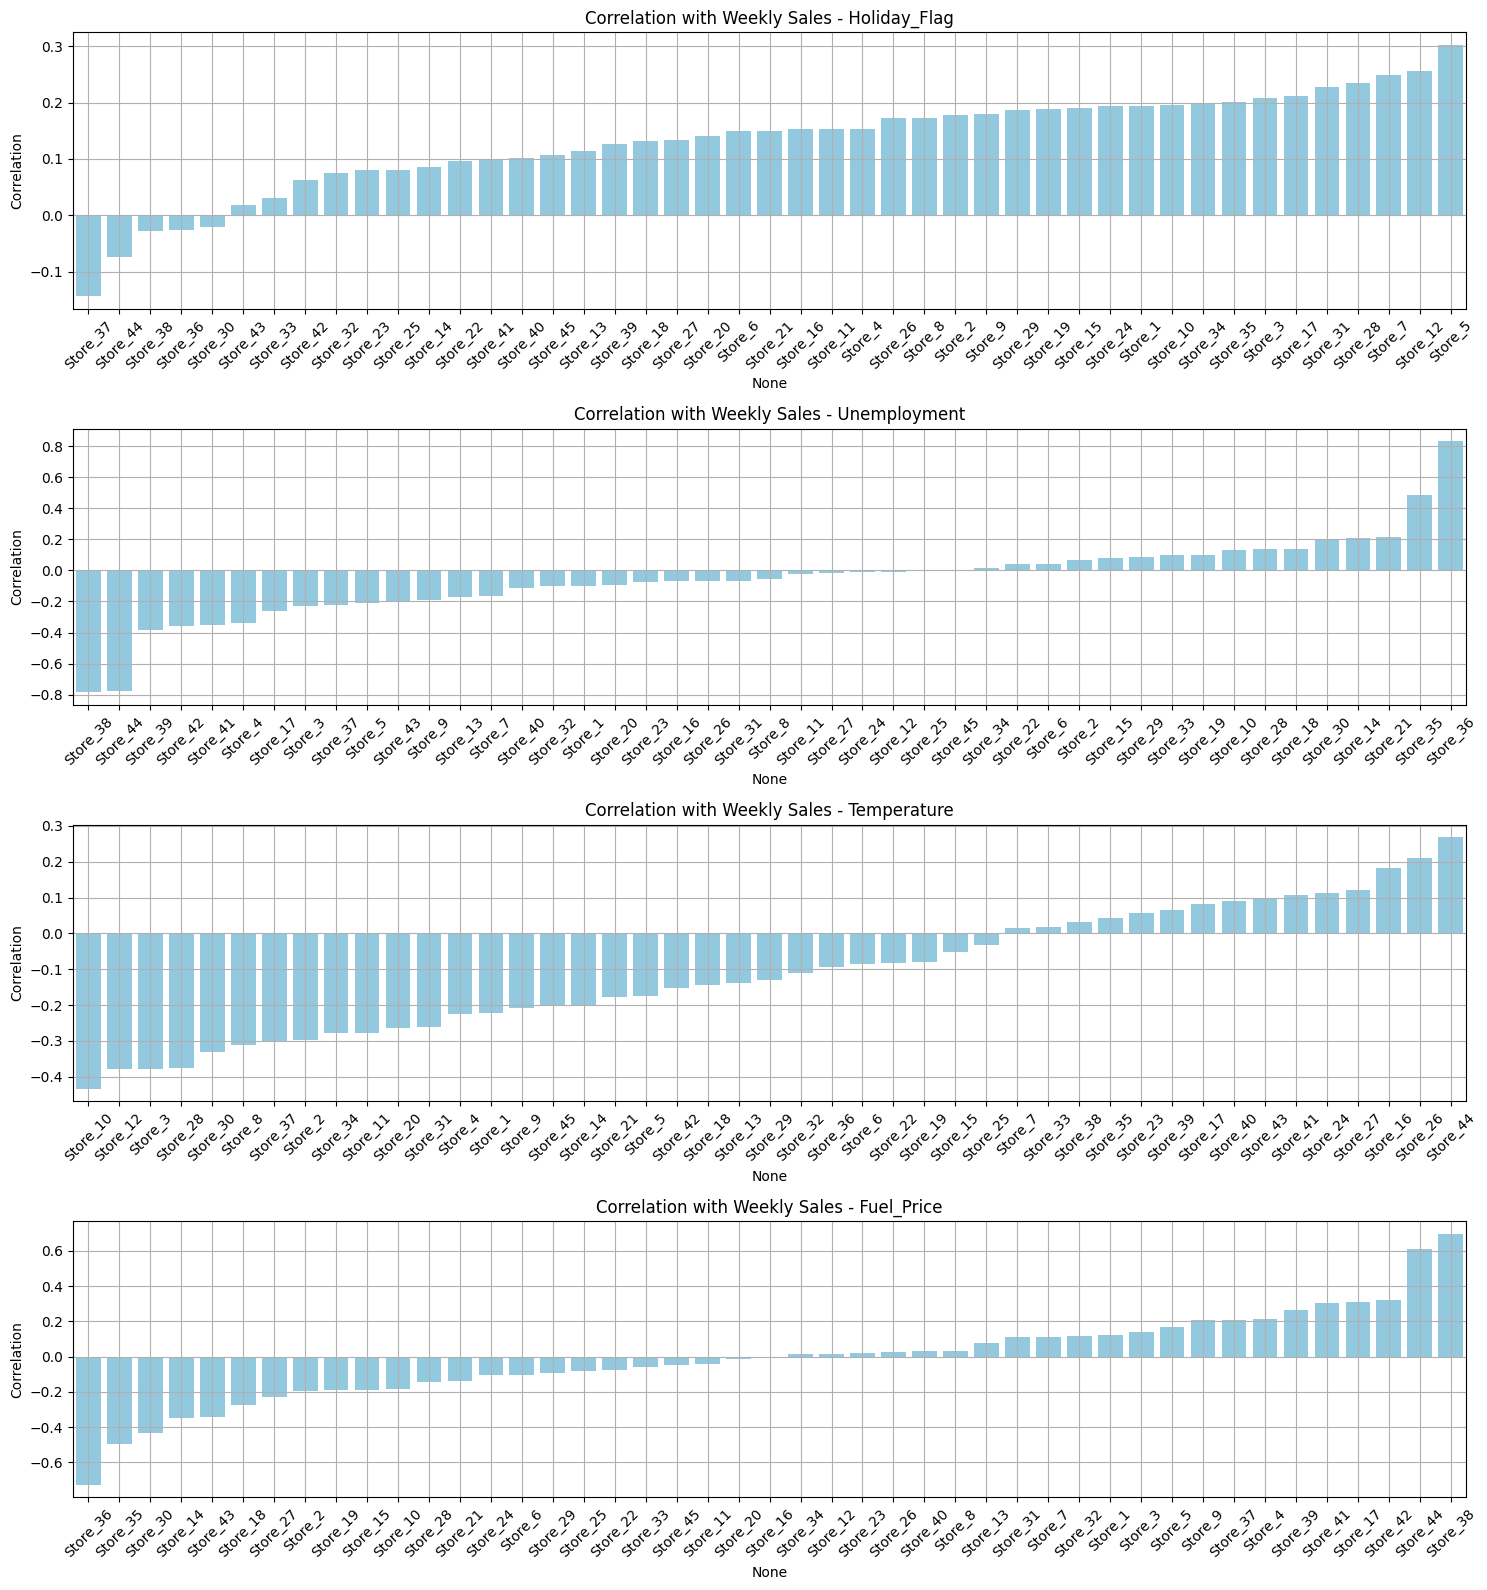

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Holiday_Flag', 'Unemployment', 'Temperature', 'Fuel_Price']
# Create separate subplots for each feature's correlation with weekly sales
fig, axes = plt.subplots(nrows=len(features), figsize=(15, len(features) * 4))
for i, feature in enumerate(features):
    # Sort the DataFrame by the feature for the current subplot
    sorted_df = store_corrT.sort_values(by=feature, ascending=True)
    sns.barplot(x=sorted_df.index, y=sorted_df[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Correlation with Weekly Sales - {feature}')
    axes[i].set_ylabel('Correlation')
    axes[i].grid(True)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Explore correlation of other features with Weekly_Sales
df.corr()['Weekly_Sales']
# Correlation shows that Fuel_Price has the least effect on the weekly_Sales
# and Unemployment has the strongest correlation with negative correlation which
# implies that unemployment goes up, the weekly_sales decreases.

Store          -0.335332
Weekly_Sales    1.000000
Holiday_Flag    0.036891
Temperature    -0.063810
Fuel_Price      0.009464
CPI            -0.072634
Unemployment   -0.106176
Name: Weekly_Sales, dtype: float64

The calculated correlation coefficient of approximately -0.0726 between CPI and Weekly Sales suggests a very weak negative correlation. This means that there is a slight tendency that as CPI increases, weekly sales might decrease slightly, and vice versa. However, the correlation is close to zero, indicating that the relationship is not strong.

In [ ]:
Highest_Wkly_Sales=df.groupby(['Store'])['Weekly_Sales'
        ].sum().reset_index().sort_values('Weekly_Sales',ascending=False)
store_list=Highest_Wkly_Sales['Store'].tolist()
highest_10=Highest_Wkly_Sales['Store'].head(10).tolist()
print(Highest_Wkly_Sales.head(10),
      f"\n\n The Ten Stores with The Highest Weekly Sales.{highest_10}")

    Store  Weekly_Sales
19     20  3.013978e+08
3       4  2.995440e+08
13     14  2.889999e+08
12     13  2.865177e+08
1       2  2.753824e+08
9      10  2.716177e+08
26     27  2.538559e+08
5       6  2.237561e+08
0       1  2.224028e+08
38     39  2.074455e+08 

 The Ten Stores with The Highest Weekly Sales.[20, 4, 14, 13, 2, 10, 27, 6, 1, 39]


Text(0, 0.5, 'Weekly_Sales')

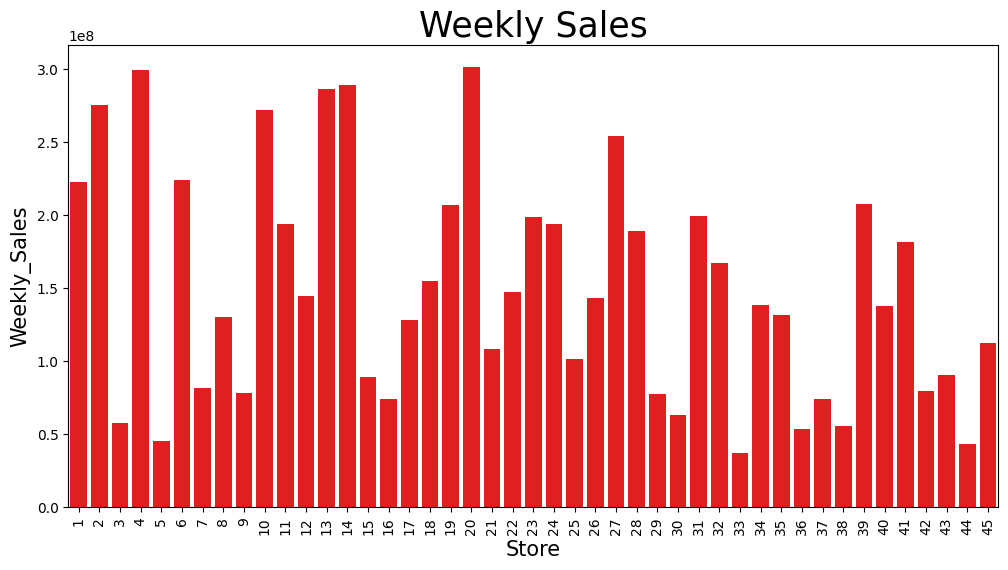

In [ ]:
fig,axes=plt.subplots(figsize=(12,6))
sns.barplot(x='Store', y='Weekly_Sales', data=Highest_Wkly_Sales, color='red')
plt.xticks(rotation=90)
plt.title('Weekly Sales', fontsize=25)
plt.xlabel('Store', fontsize=15)
plt.ylabel('Weekly_Sales', fontsize=15)

In [ ]:
# show the average Weekly_sales of all stores:
Avg_Wkly_Sales=df.groupby(['Store'])['Weekly_Sales'].mean().reset_index().sort_values(
                            'Weekly_Sales', ascending=(False))
Avg_Wkly_Sales.head(10)

,Store,Weekly_Sales
19,20,2.107677e+06
3,4,2.094713e+06
13,14,2.020978e+06
12,13,2.003620e+06
1,2,1.925751e+06
9,10,1.899425e+06
26,27,1.775216e+06
5,6,1.564728e+06
0,1,1.555264e+06
38,39,1.450668e+06


c. Does temperature affect the weekly sales in any manner?
Ans. Observation: As Temperature increase in summer sales are not as high as in winter which indicates that people go out less frequently in summer due to high temperatures

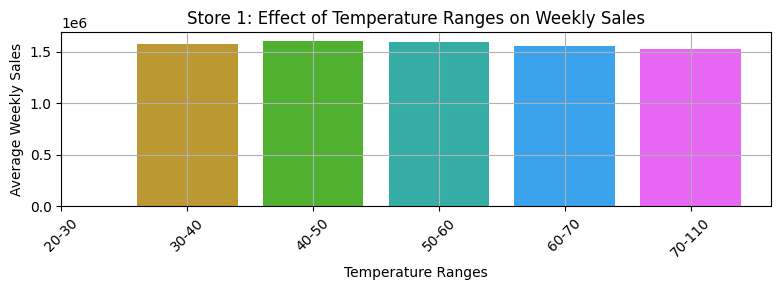

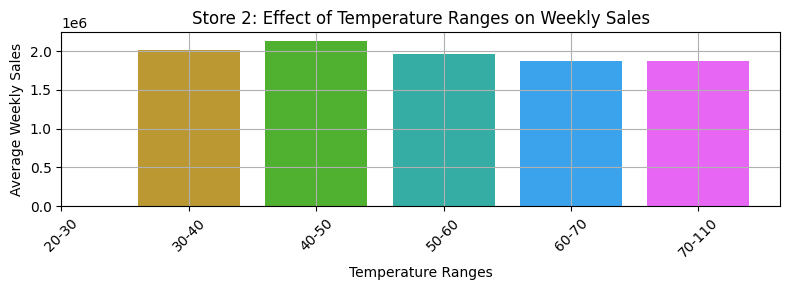

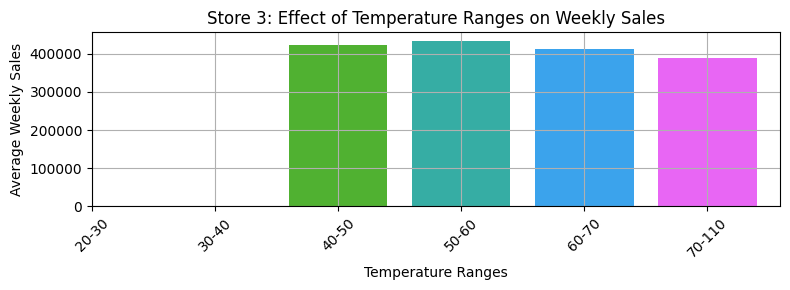

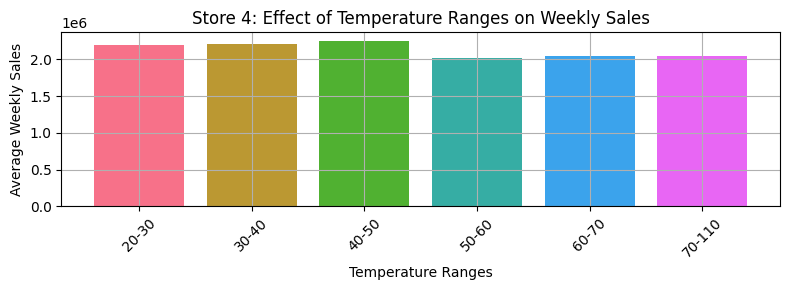

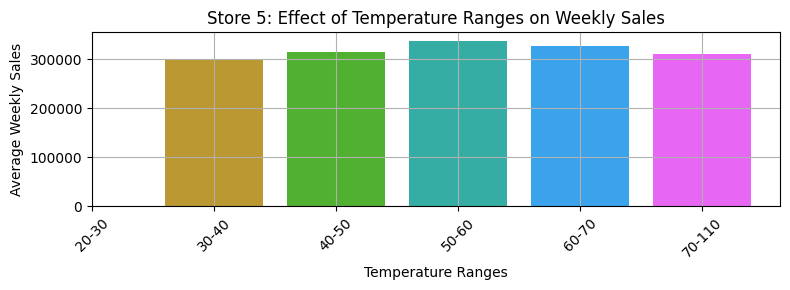

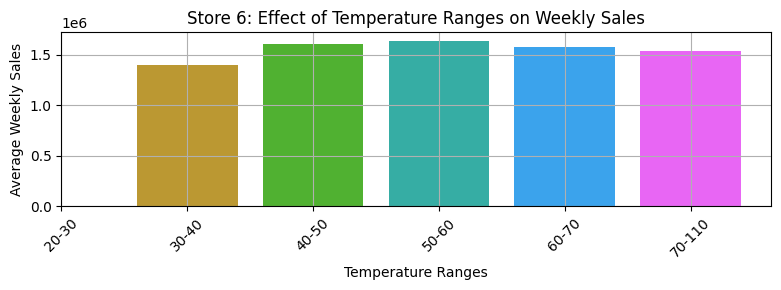

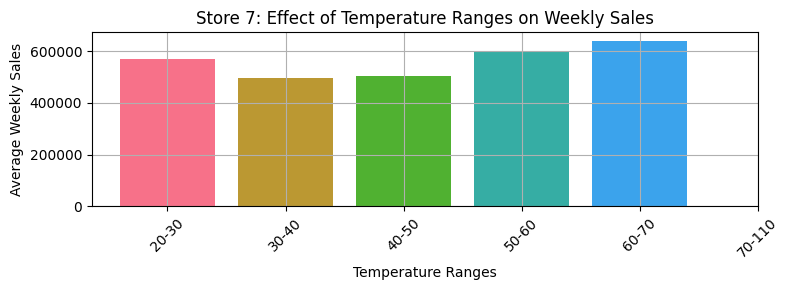

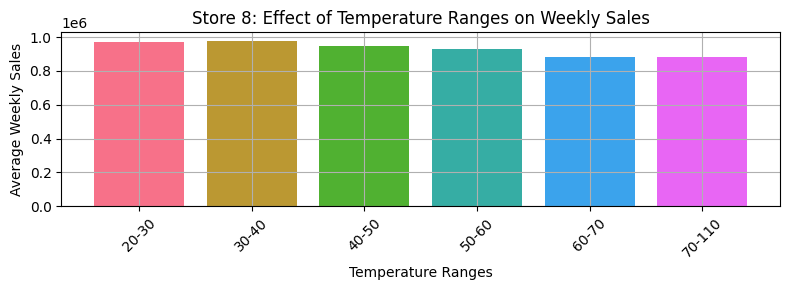

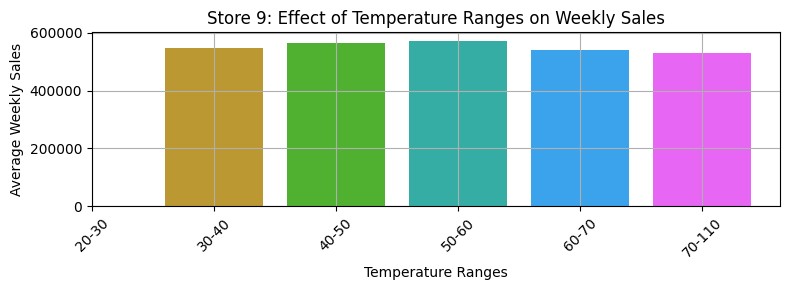

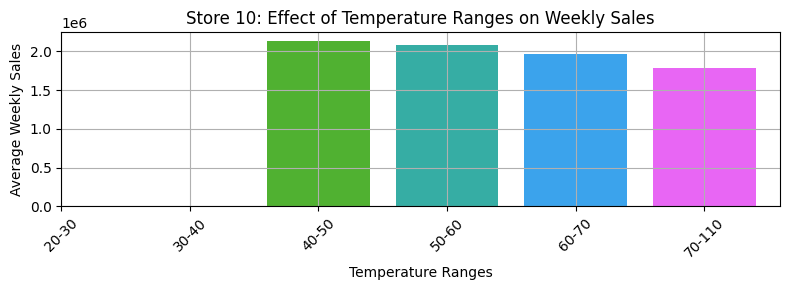

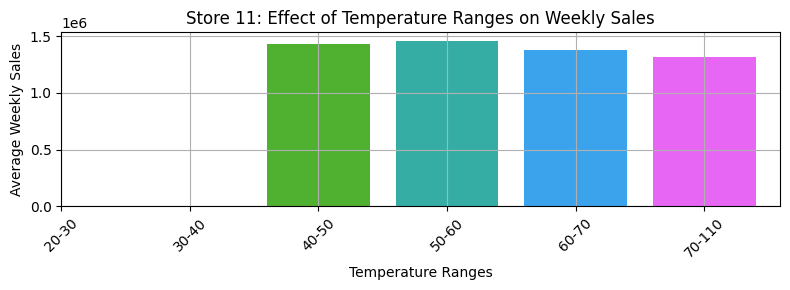

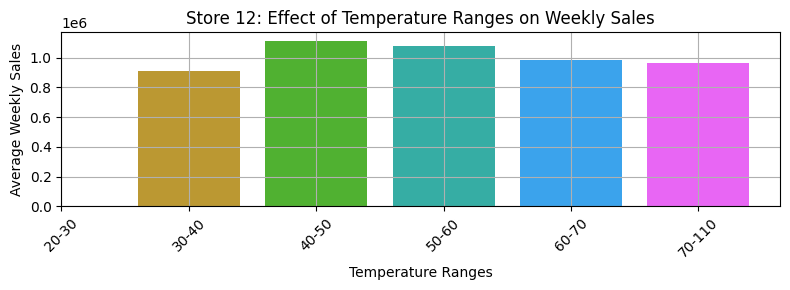

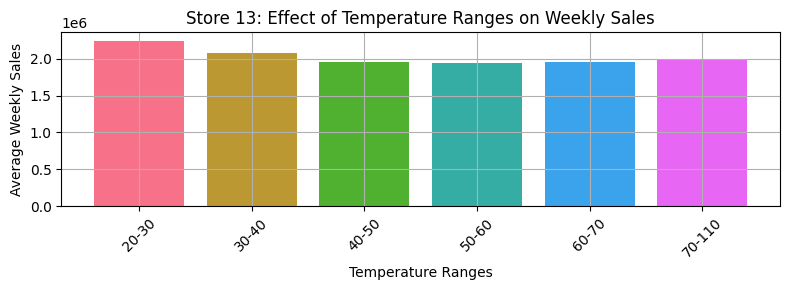

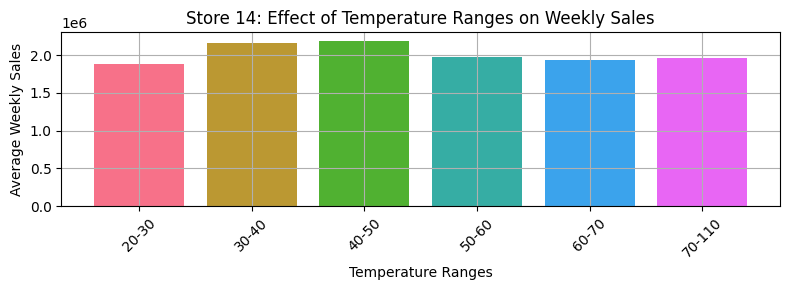

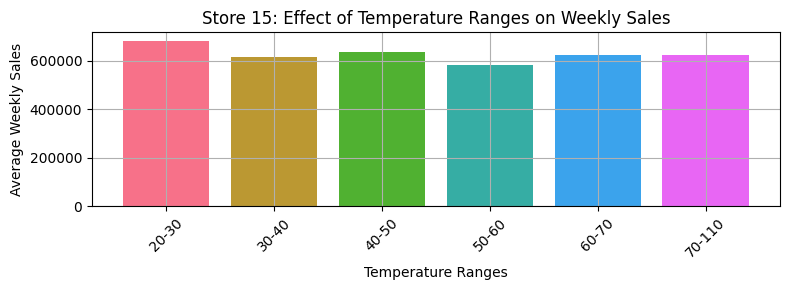

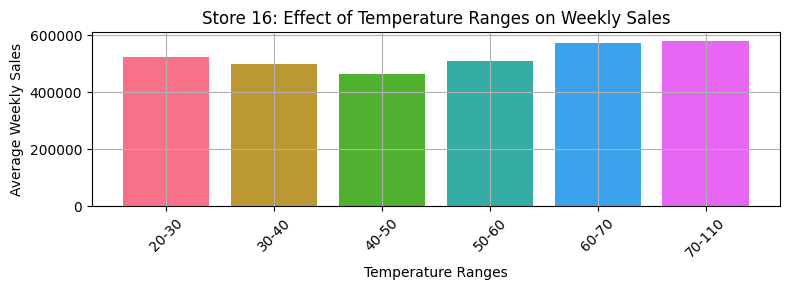

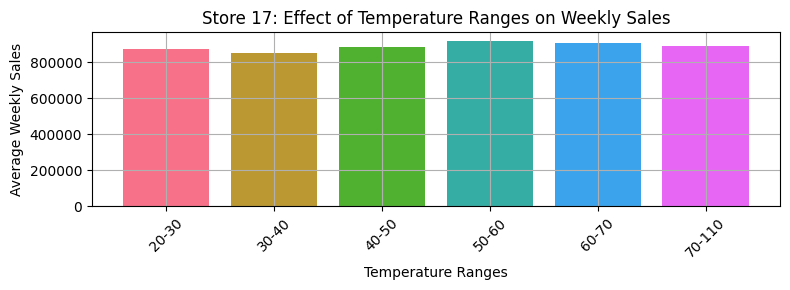

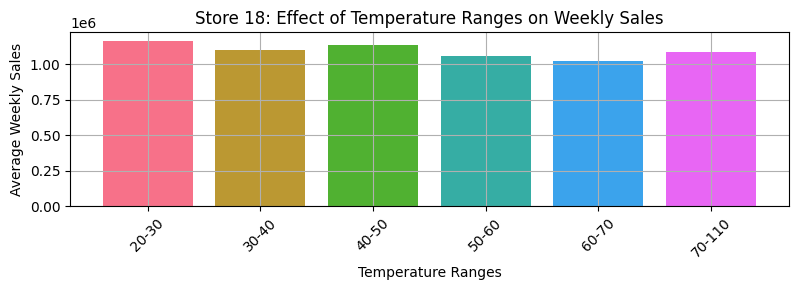

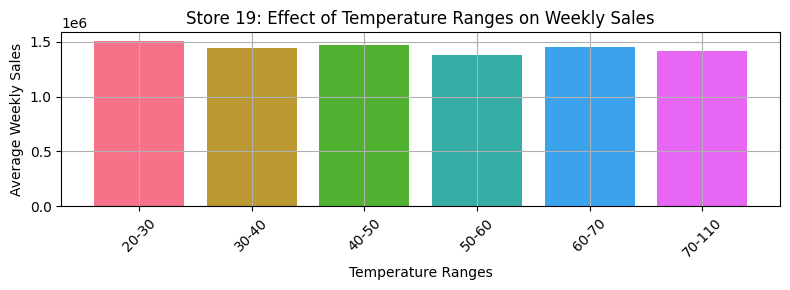

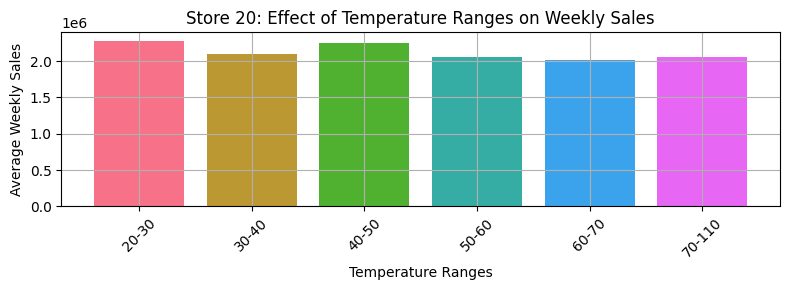

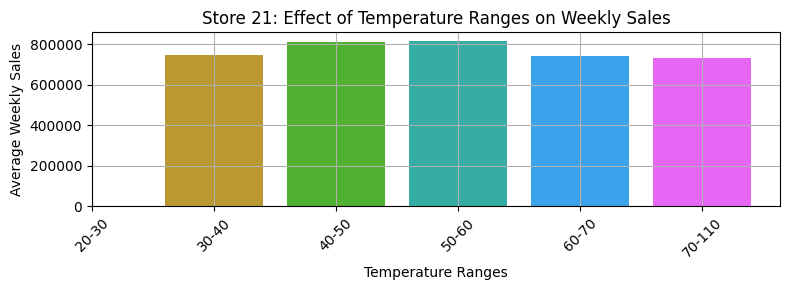

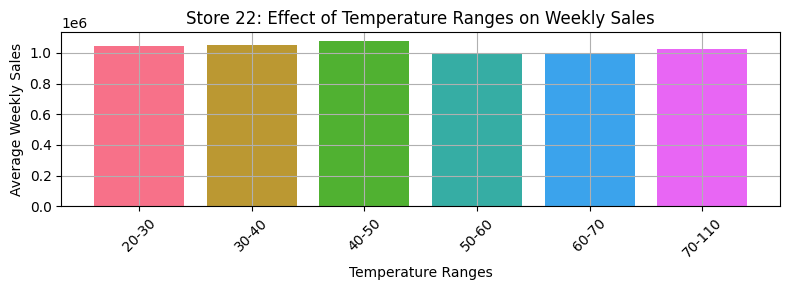

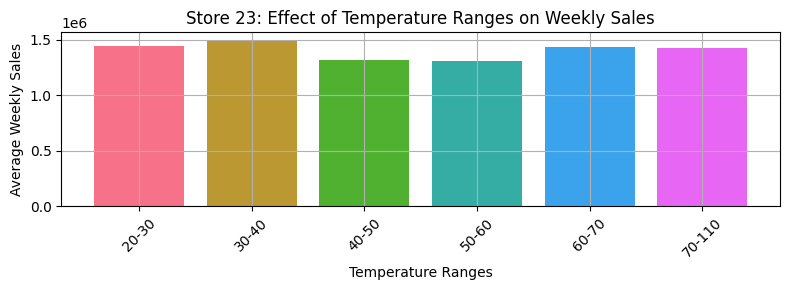

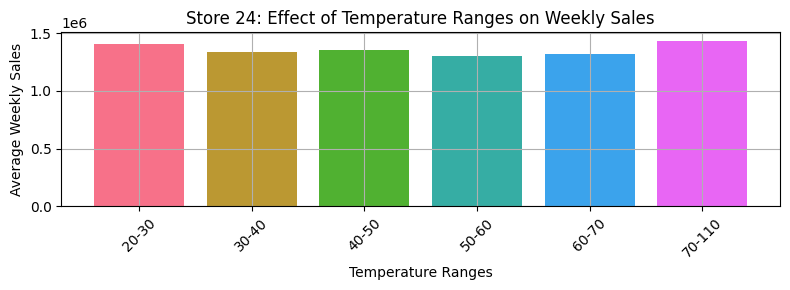

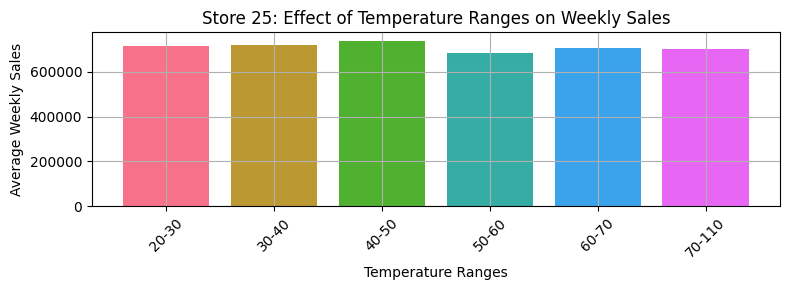

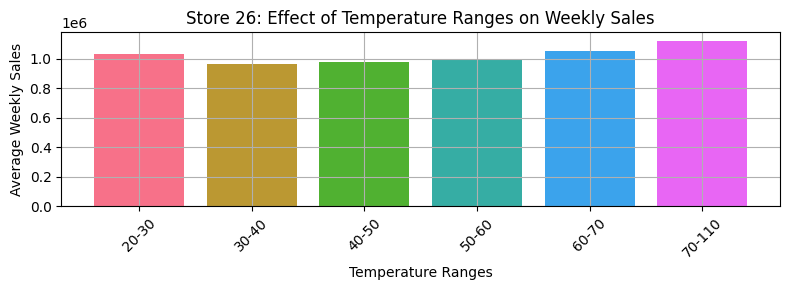

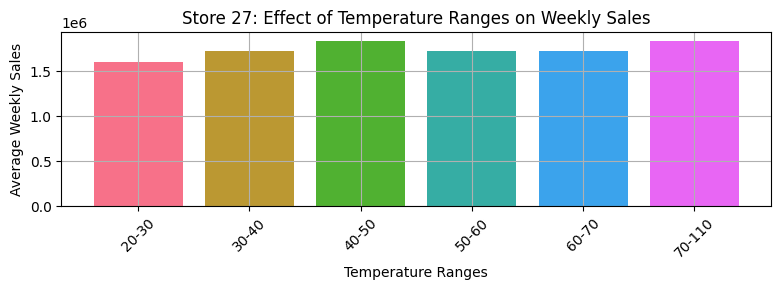

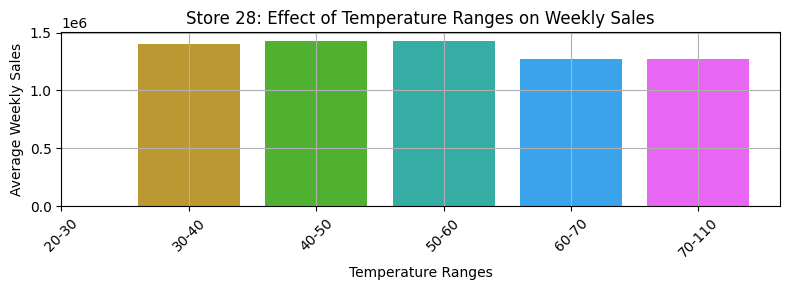

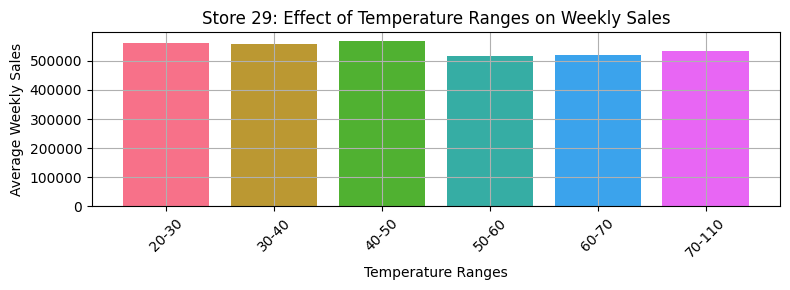

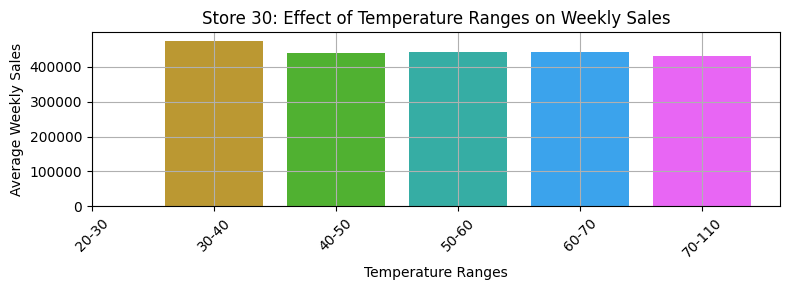

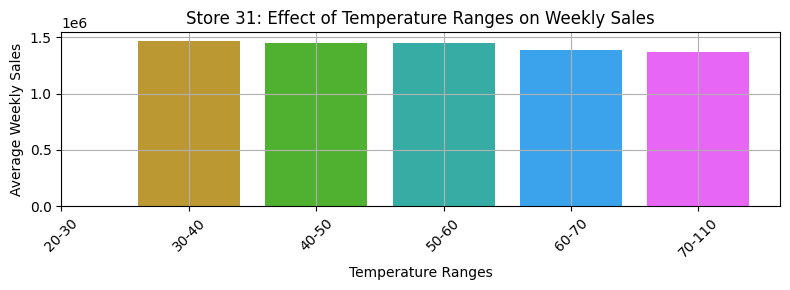

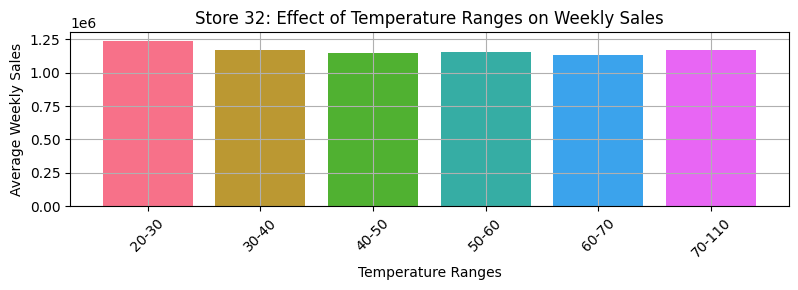

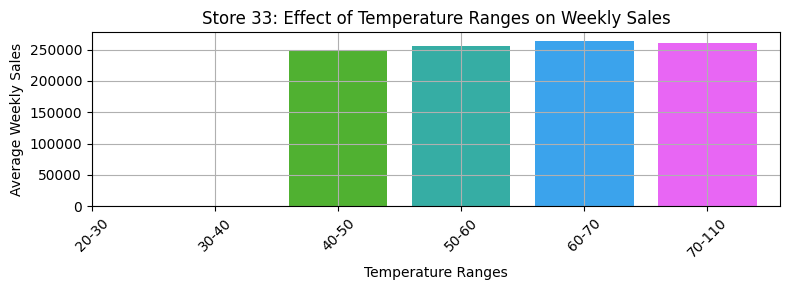

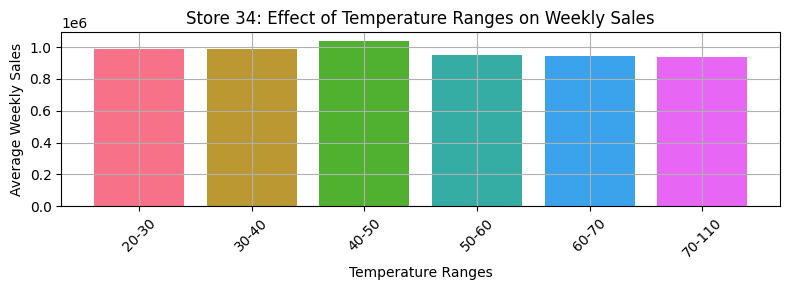

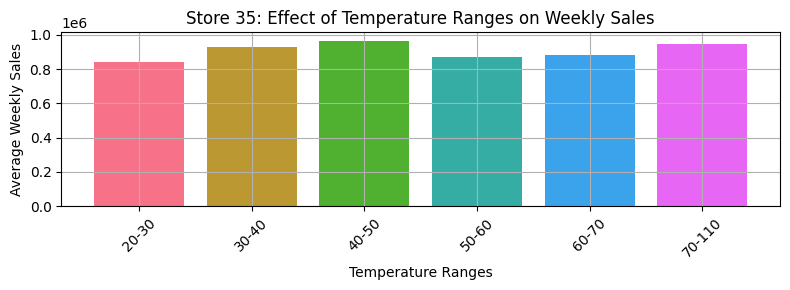

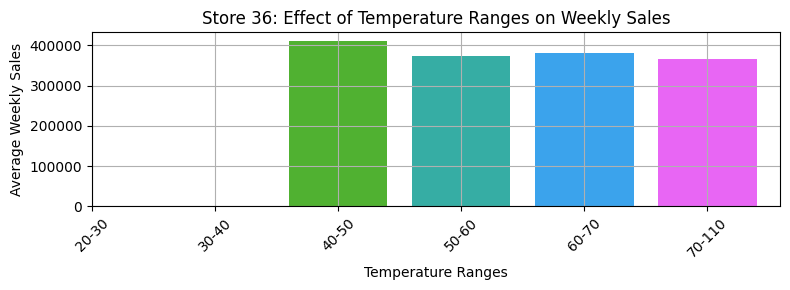

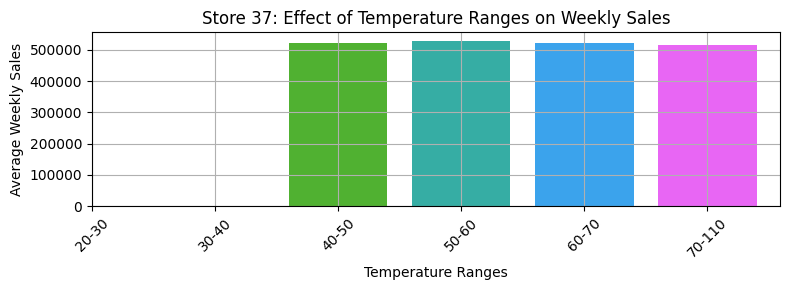

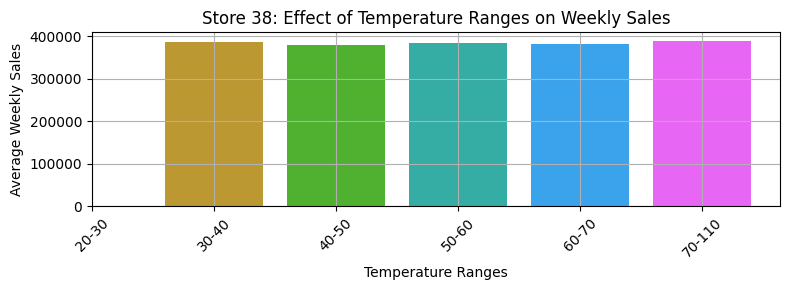

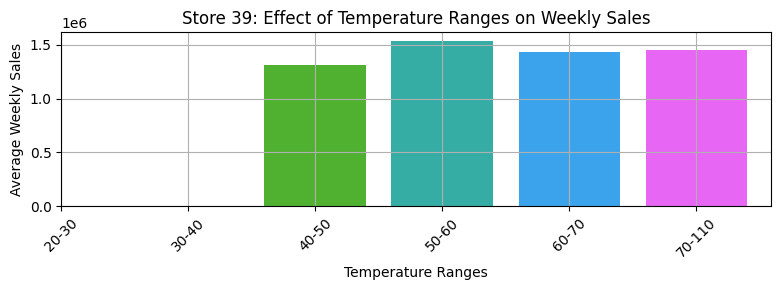

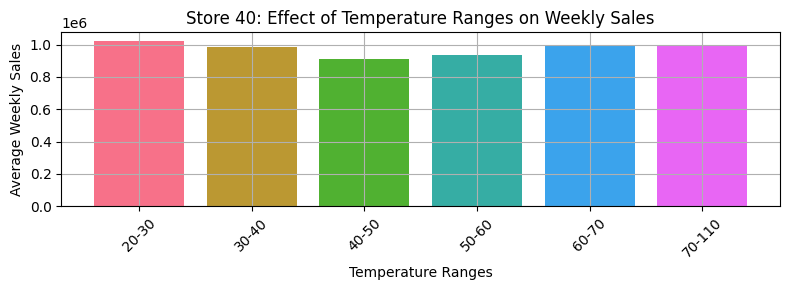

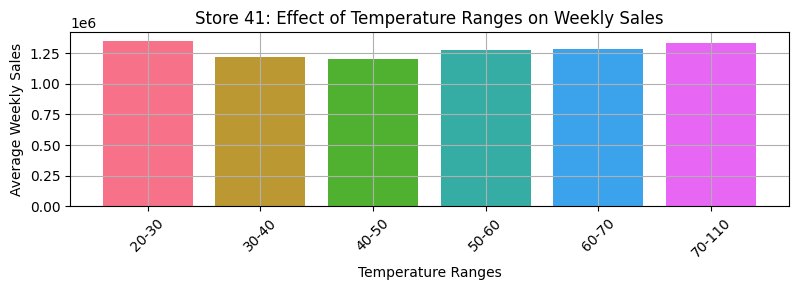

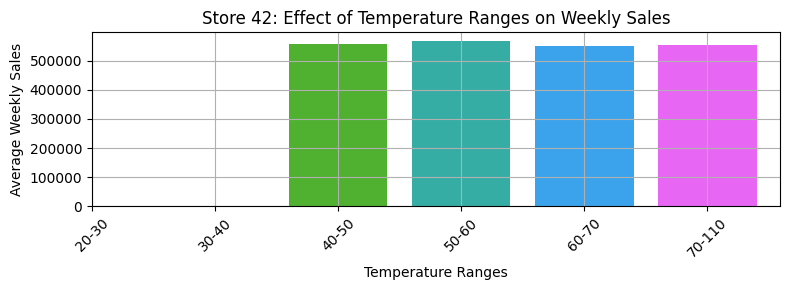

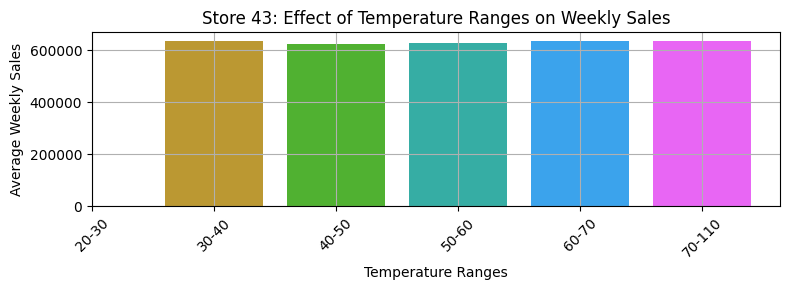

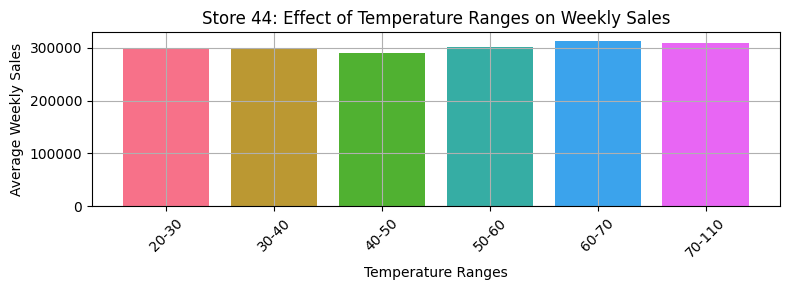

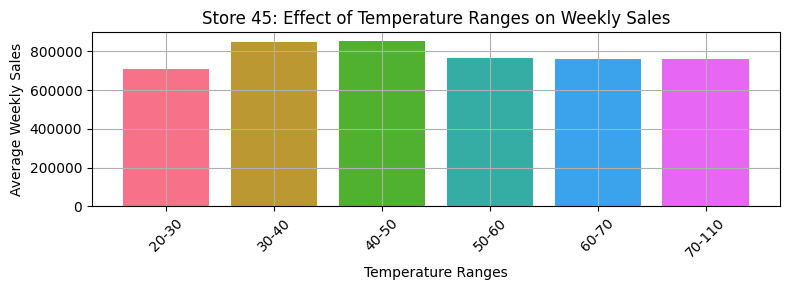

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create temperature ranges
temperature_ranges = [(20, 30), (30, 40), (40, 50), (50, 60), (60, 70), (70, 110)]

# Generate a color palette for the temperature ranges
palette = sns.color_palette("husl", len(temperature_ranges))

# Iterate through stores and plot individual graphs
for i in range(1, 46):
    store_data = df[df['Store'] == i]  # Filter data for the current store

    # Group temperature into ranges and calculate average weekly sales for each range
    temp_sales = []
    for temp_range in temperature_ranges:
        lower_temp, upper_temp = temp_range
        temp_range_data = store_data[(store_data['Temperature'] >= lower_temp) & (store_data['Temperature'] < upper_temp)]
        avg_sales = temp_range_data['Weekly_Sales'].mean()
        temp_sales.append(avg_sales)

    # Plotting the average sales against temperature ranges with a color palette
    plt.figure(figsize=(8, 3))  # Adjust figure size as needed
    plt.bar(range(len(temperature_ranges)), temp_sales, color=palette)
    plt.title(f'Store {i}: Effect of Temperature Ranges on Weekly Sales')
    plt.xlabel('Temperature Ranges')
    plt.ylabel('Average Weekly Sales')
    plt.xticks(range(len(temperature_ranges)), [f'{t[0]}-{t[1]}' for t in temperature_ranges], rotation=45)
    plt.grid(True)  # Display grid lines
    plt.tight_layout()  # Adjust plot layout
    plt.show()


Text(0.5, 1.0, 'Weekly Sales vs. Temperature Over Time')

<Figure size 1000x500 with 0 Axes>

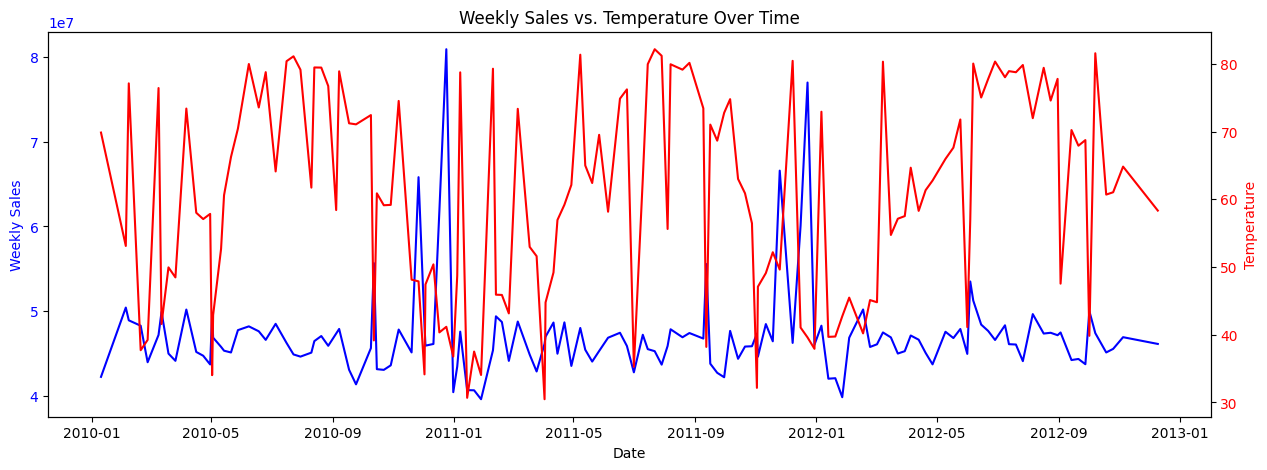

In [ ]:
temp_mean= df.groupby('Date')['Temperature'].mean().reset_index()
date_sales = df.groupby("Date")[["Weekly_Sales"]].sum().reset_index()
plt.figure(figsize=(10,5))
date_sales= pd.merge(temp_mean, date_sales, on='Date', how='inner')
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(date_sales['Date'], date_sales['Weekly_Sales'], color='b', label='Weekly Sales')
ax1.set_xlabel('Date')
ax1.set_ylabel('Weekly Sales', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(date_sales['Date'], date_sales['Temperature'], color='r', label='Temperature')
ax2.set_ylabel('Temperature', color='r')
ax2.tick_params(axis='y', labelcolor='r')


plt.title('Weekly Sales vs. Temperature Over Time')

Observation: As Temperature increase in summer sales are not as high as in winter which indicates that people go out less frequently in summer due to high temperatures

d. How is the Consumer Price index affecting the weekly sales of various stores?
Ans. Although there is inflation over time represented by increasing CPI over the time period. There is no upward or downward trend followed by weekly sales.

<Axes: xlabel='Date', ylabel='Weekly_Sales'>

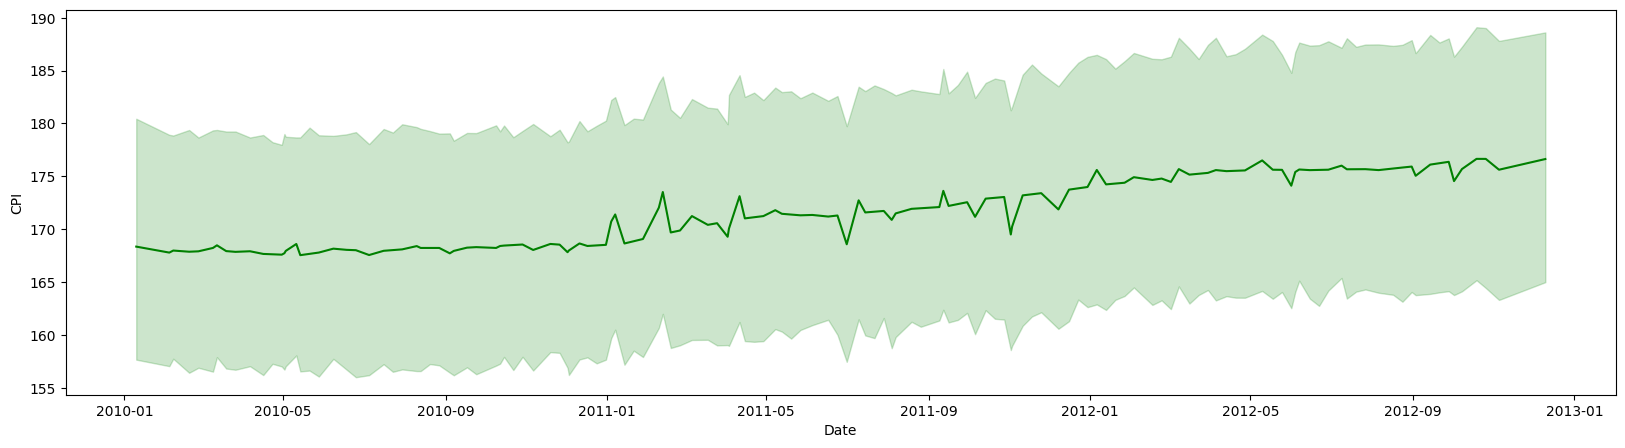

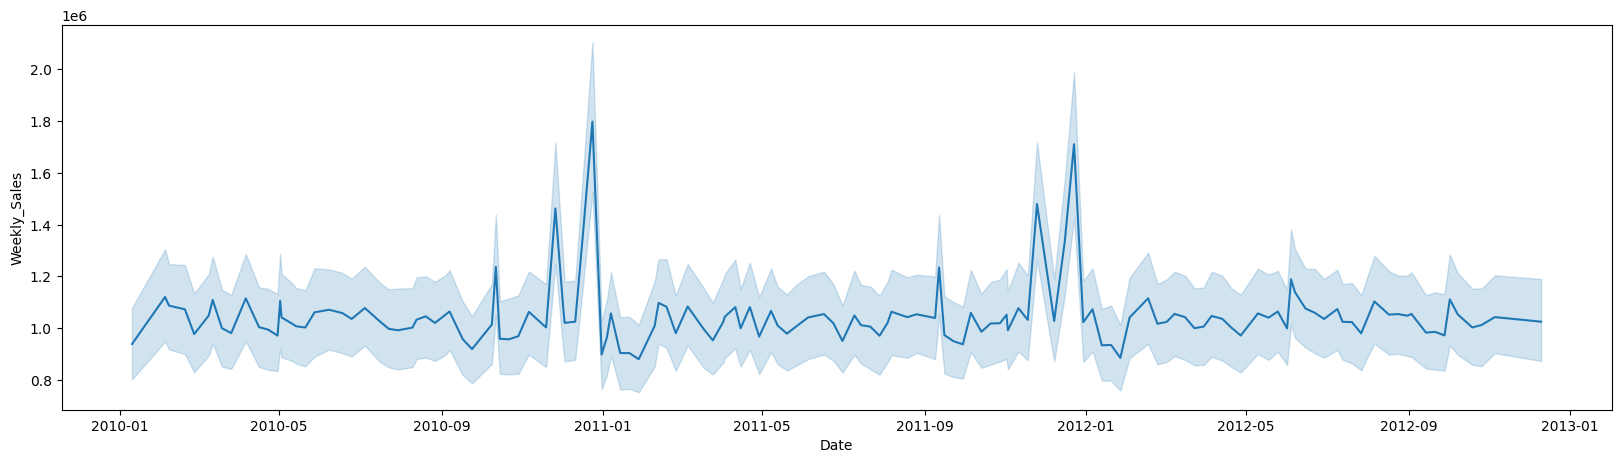

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(data=df,x='Date',y='CPI',color='green')

plt.figure(figsize=(20,5))
sns.lineplot(data=df["Weekly_Sales"])

Although there is inflation over time represented by increasing CPI over the time period. There is no upward or downward trend followed by weekly sales.

e. Top performing stores according to the historical data
Ans. Store numbers :20, 4, 14, 13, 2, 10, 27, 6, 1, 39

[20, 4, 14, 13, 2, 10, 27, 6, 1, 39]


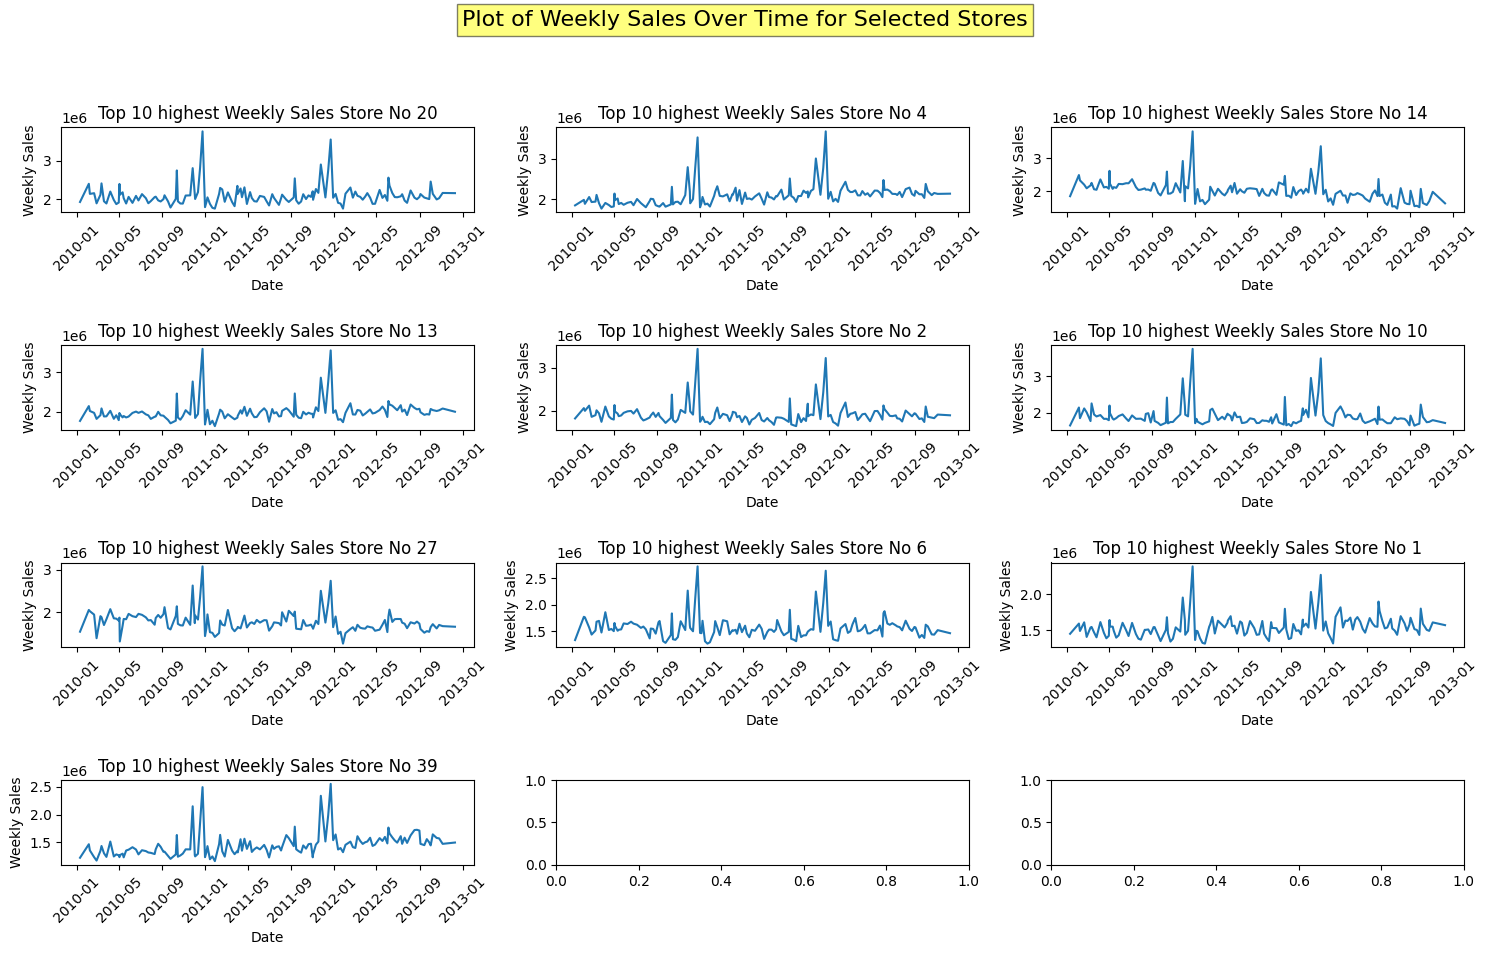

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
print(highest_10)
top_stores_data = df[df['Store'].isin(highest_10[:10])]
weekly_sales_by_store = top_stores_data.groupby(['Store', 'Date'])['Weekly_Sales'].sum().reset_index()
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
fig.suptitle('Plot of Weekly Sales Over Time for Selected Stores', fontsize=16, bbox=dict(facecolor='yellow', alpha=0.5))

for i, store in enumerate(highest_10[:10]):
    store_data = weekly_sales_by_store[weekly_sales_by_store['Store'] == store]
    row, col = divmod(i, 3)
    axes[row, col].plot(store_data['Date'], store_data['Weekly_Sales'])
    axes[row, col].set_title(f'Top 10 highest Weekly Sales Store No {store}')
    axes[row, col].set_xlabel('Date')
    axes[row, col].set_ylabel('Weekly Sales')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Outlier investigation - Examine outliers for Weekly_Sales on all the Stores
Its observed that only stores 36,38,42,43 and 44 have minimal or no outliers

In [ ]:

def outlier_plot(xrange, l=5, w=2, wl=20, ww=10, hs=1.5):
    fig, axes = plt.subplots(l, w, figsize=(wl, ww))
    plt.subplots_adjust(hspace=hs)
    j = 1
    for i in xrange:
        store_df = get_store_df(df, 'Store', i)
        plt.subplot(l, w, j)
        sns.boxplot(x=store_df['Weekly_Sales'])
        plt.title(f"Store:{i}", fontsize=15)
        j += 1

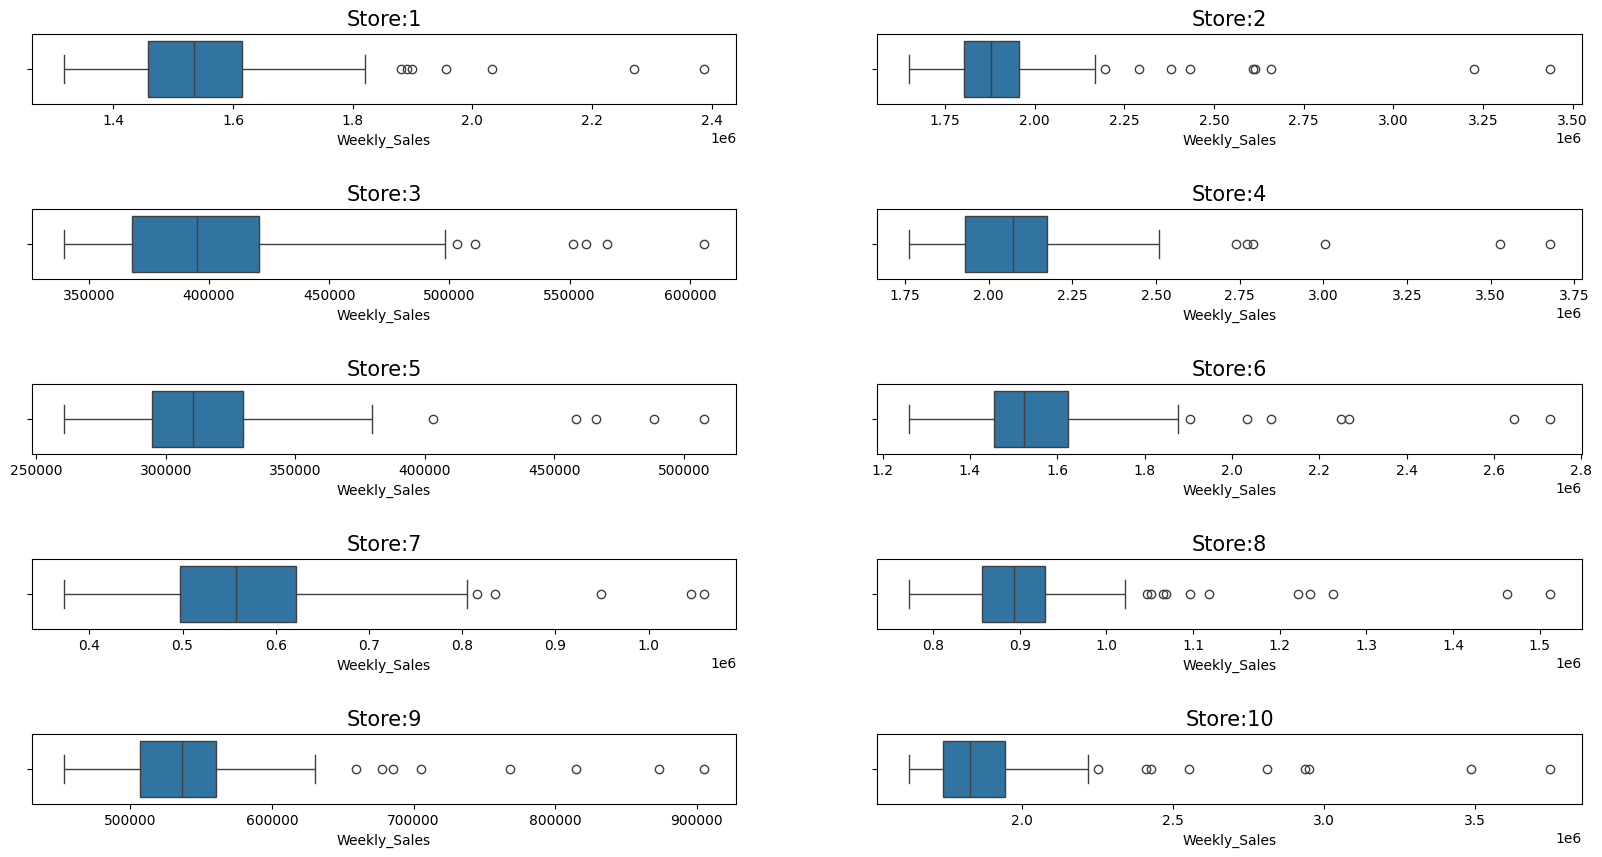

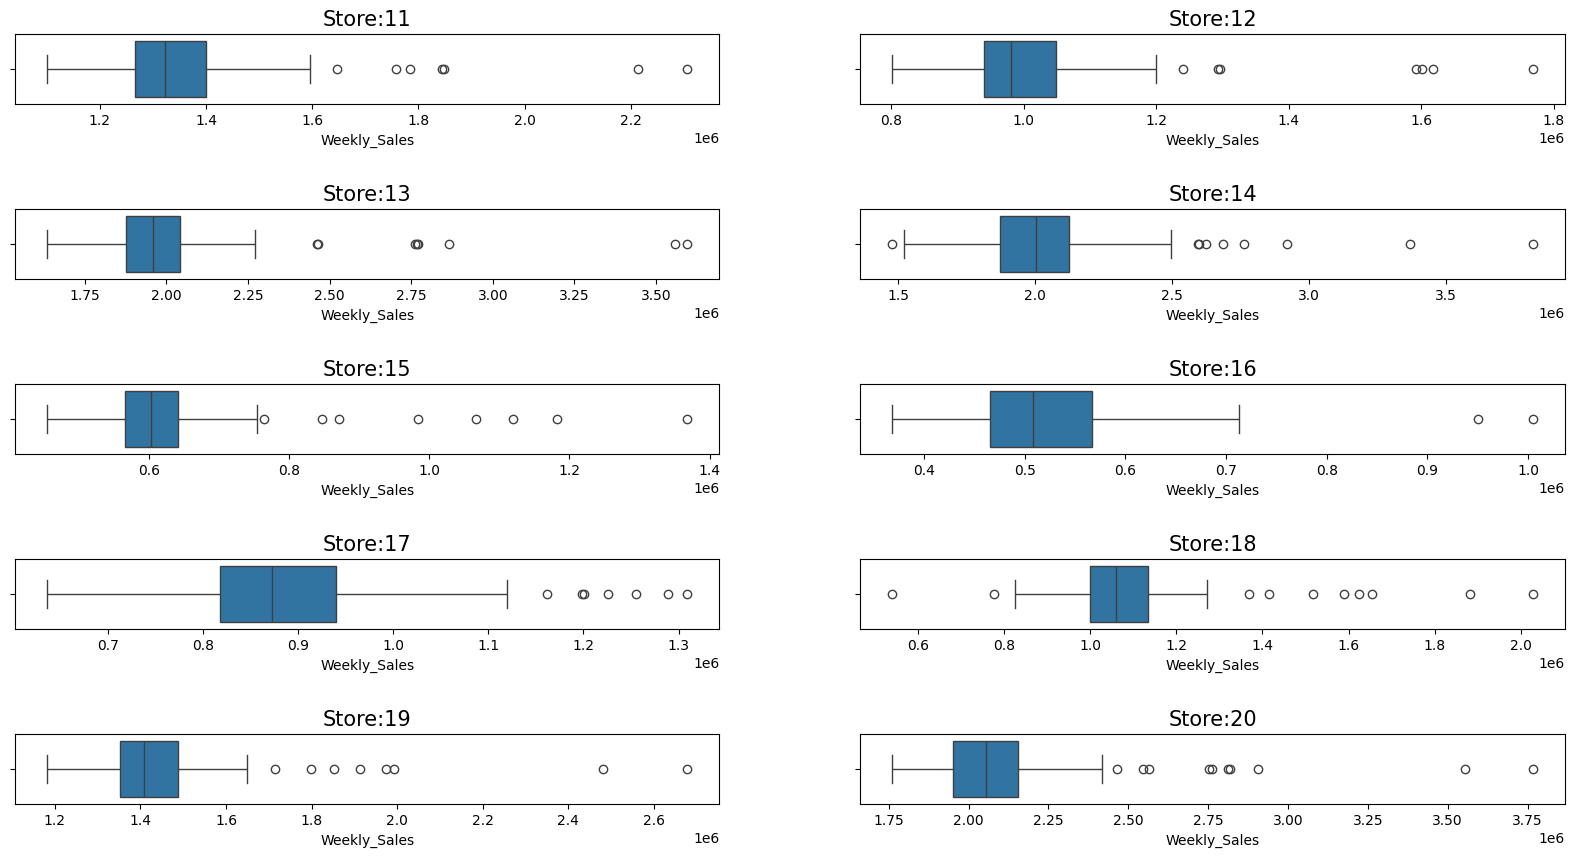

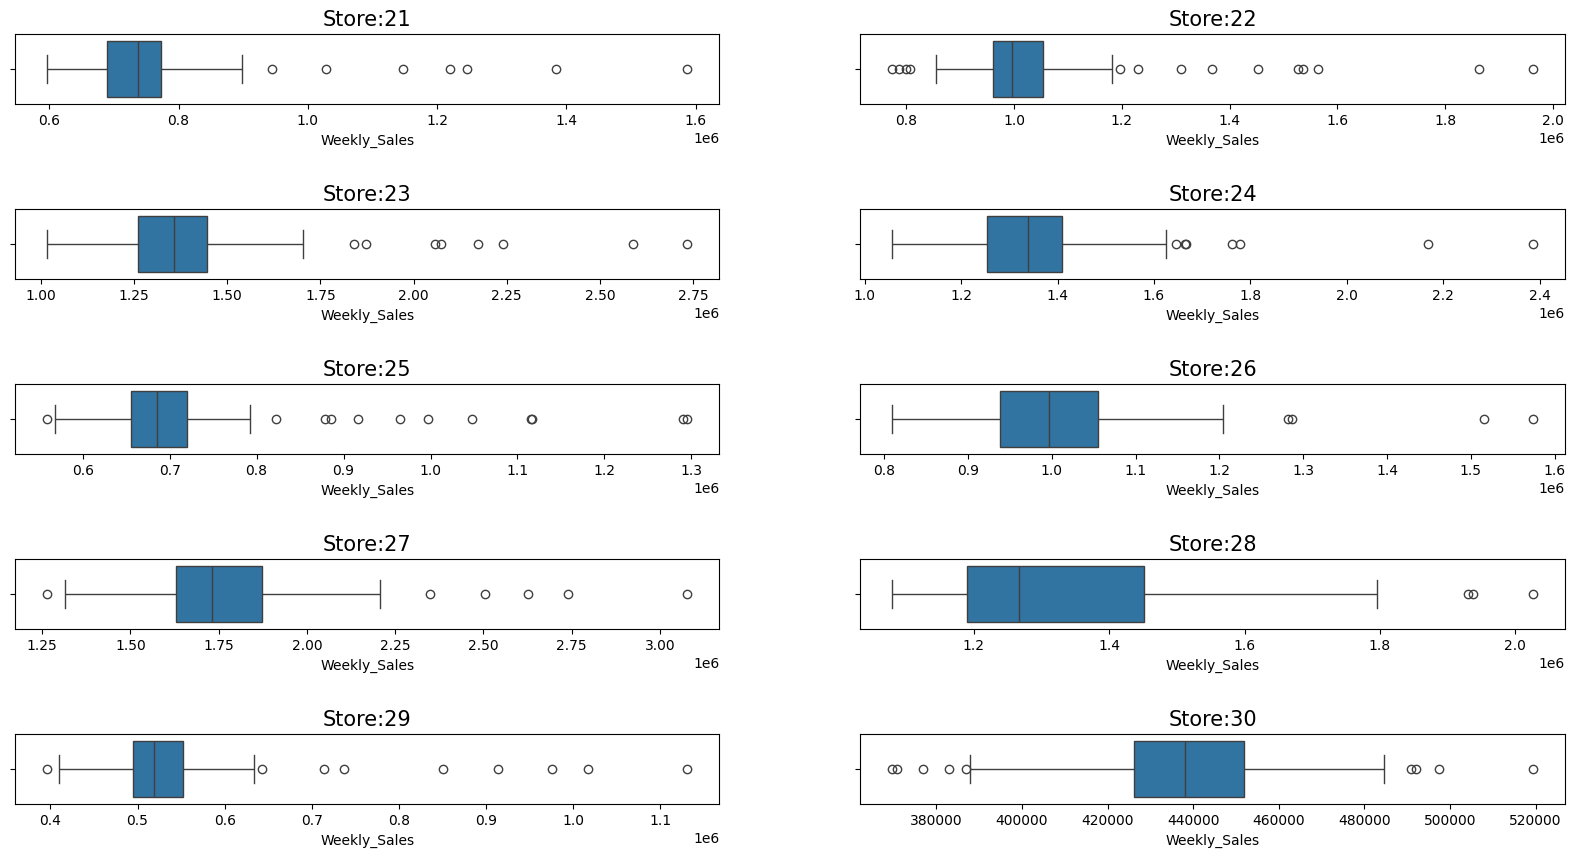

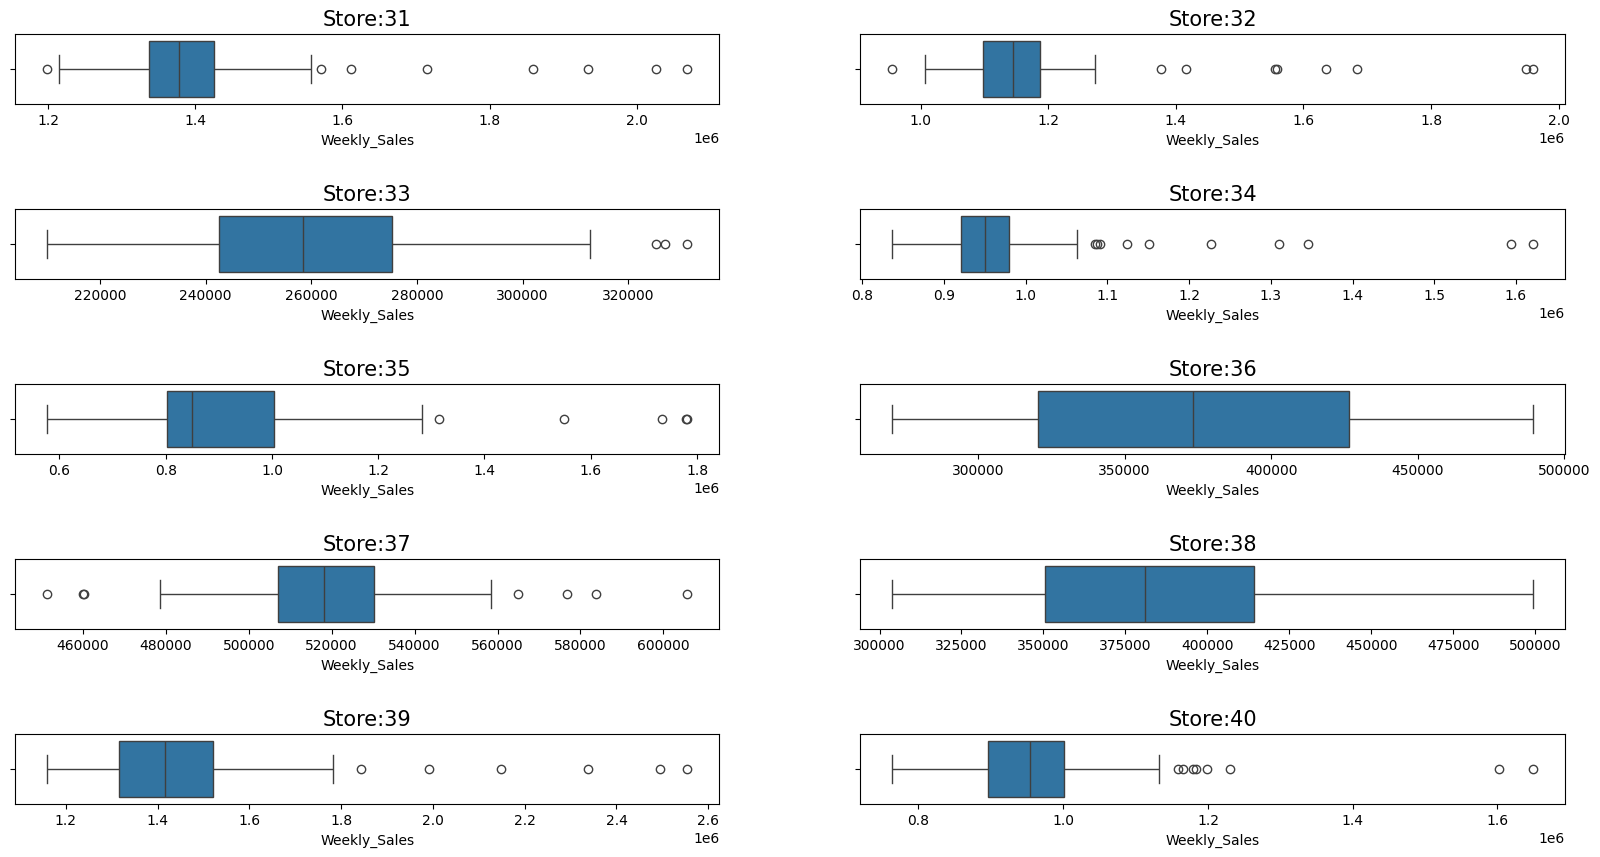

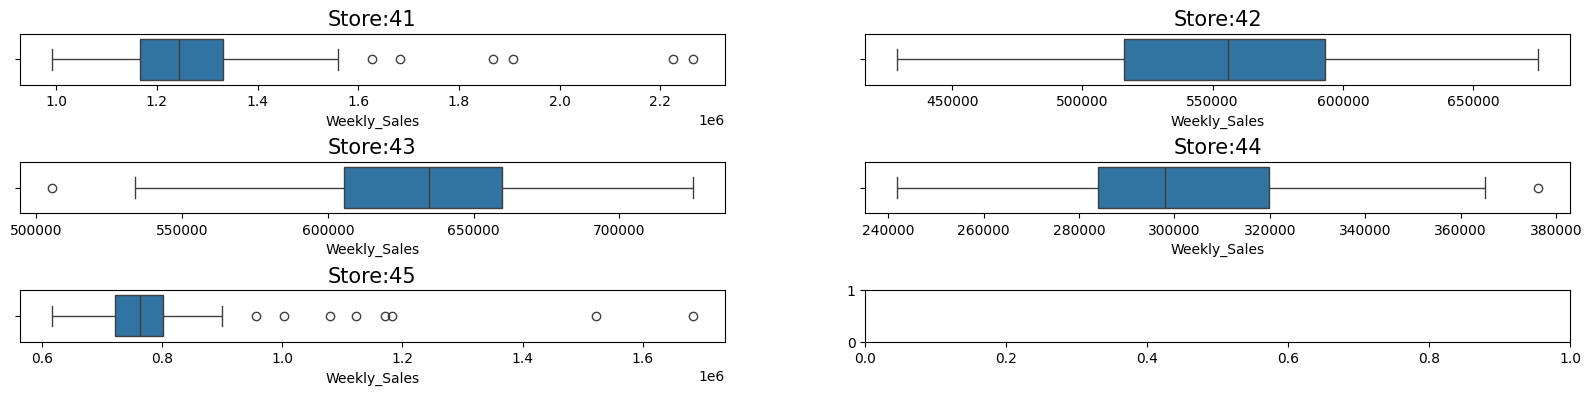

In [ ]:

# Boxplot of weekly_sales for Stores 1:45 (in ranges)
outlier_plot(range(1,11))
outlier_plot(range(11,21))
outlier_plot(range(21,31))
outlier_plot(range(31,41))
outlier_plot(range(41,46),3,2,20,4)

Its observed that only stores 36,38,42,43 and 44 have minimal or no outliers

### ADF Test

In [ ]:
WkSales = df.groupby(['Store'])['Weekly_Sales'].sum().reset_index().sort_values('Store',ascending=True)
Store_list = WkSales['Store'].tolist()

In [ ]:
from statsmodels.tsa.stattools import adfuller
p_value_x, p_value_y = [], []
Test_stat_x, Test_stat_y = [], []
store_x, store_y = [], []

for i in Store_list:
    store_df = get_store_df(df, 'Store', i)
    adft = adfuller(store_df['Weekly_Sales'], autolag='AIC')

    p_value = adft[1]
    Test_stat = adft[0]

    if p_value > 0.05:
        store_x.append(i)
        p_value_x.append(p_value)
        Test_stat_x.append(Test_stat)
    else:
        store_y.append(i)
        p_value_y.append(p_value)
        Test_stat_y.append(Test_stat)

xstores = pd.DataFrame(zip(store_x, p_value_x, Test_stat_x),
                       columns=['Store', 'p_value', 'Test Statistics'])
ystores = pd.DataFrame(zip(store_y, p_value_y, Test_stat_y),
                       columns=['Store', 'p_value', 'Test Statistics'])

print(f"\nNon-Stationary Time Series (Stores):\nDick Fowler Test Results for p-values greater than 0.05\n{xstores}")
print(f"\nStationary Time Series (Stores):\nDick Fowler Test Results for p-values less than 0.05\n{ystores}")


Non-Stationary Time Series (Stores):
Dick Fowler Test Results for p-values greater than 0.05
   Store   p_value  Test Statistics
0     14  0.067870        -2.736887
1     30  0.168364        -2.311254
2     36  0.973016         0.213632
3     38  0.916563        -0.360017
4     42  0.457285        -1.649531
5     43  0.106059        -2.539930
6     44  0.759162        -0.983703

Stationary Time Series (Stores):
Dick Fowler Test Results for p-values less than 0.05
    Store       p_value  Test Statistics
0       1  1.387779e-05        -5.102186
1       2  3.990207e-03        -3.708863
2       3  3.840926e-02        -2.963868
3       4  4.779866e-02        -2.879382
4       5  4.251706e-04        -4.310974
5       6  2.159486e-06        -5.492502
6       7  2.170072e-04        -4.476254
7       8  1.002746e-06        -5.647653
8       9  2.134309e-05        -5.008564
9      10  8.763068e-06        -5.200703
10     11  3.316837e-03        -3.762354
11     12  1.045184e-06        -5.63934

In [ ]:
Highest_Wkly_Sales=df.groupby(['Store'])['Weekly_Sales'
        ].sum().reset_index().sort_values('Weekly_Sales',ascending=False)

store_list=Highest_Wkly_Sales['Store'].tolist()
highest_10=Highest_Wkly_Sales['Store'].head(10).tolist()
print(Highest_Wkly_Sales.head(10),
      f"\n\n The Ten Stores with The Highest Weekly Sales.{highest_10}")

    Store  Weekly_Sales
19     20  3.013978e+08
3       4  2.995440e+08
13     14  2.889999e+08
12     13  2.865177e+08
1       2  2.753824e+08
9      10  2.716177e+08
26     27  2.538559e+08
5       6  2.237561e+08
0       1  2.224028e+08
38     39  2.074455e+08 

 The Ten Stores with The Highest Weekly Sales.[20, 4, 14, 13, 2, 10, 27, 6, 1, 39]


f. The worst performing store, and how significant is the difference between the
highest and lowest performing stores.
Ans.
Worst Performing Store:  33  

Difference Between Highest and Lowest Performing Stores: 264237570.49999997

In [ ]:
import pandas as pd
# Calculate total weekly sales for each store
store_sales = df.groupby('Store')['Weekly_Sales'].sum().reset_index()

# Identify the top performing stores
top_performing_stores = store_sales.sort_values('Weekly_Sales', ascending=False).head(5)
# Change 'head(5)' to any number if you want a different number of top performing stores

# Identify the worst performing store
worst_performing_store = store_sales.sort_values('Weekly_Sales').head(1)

# Calculate the difference between the highest and lowest performing stores
difference_highest_lowest = top_performing_stores['Weekly_Sales'].max() - worst_performing_store['Weekly_Sales'].min()

# Print results
print(f"Top Performing Stores:\n{top_performing_stores}")
print(f"\nWorst Performing Store:\n{worst_performing_store}")
print(f"\nDifference Between Highest and Lowest Performing Stores: {difference_highest_lowest}")


Top Performing Stores:
    Store  Weekly_Sales
19     20  3.013978e+08
3       4  2.995440e+08
13     14  2.889999e+08
12     13  2.865177e+08
1       2  2.753824e+08

Worst Performing Store:
    Store  Weekly_Sales
32     33   37160221.96

Difference Between Highest and Lowest Performing Stores: 264237570.49999997


b. If the weekly sales show a seasonal trend, when and what could be the reason?
 Ans .The weekly sales show a seasonal trend, when holiday are there.

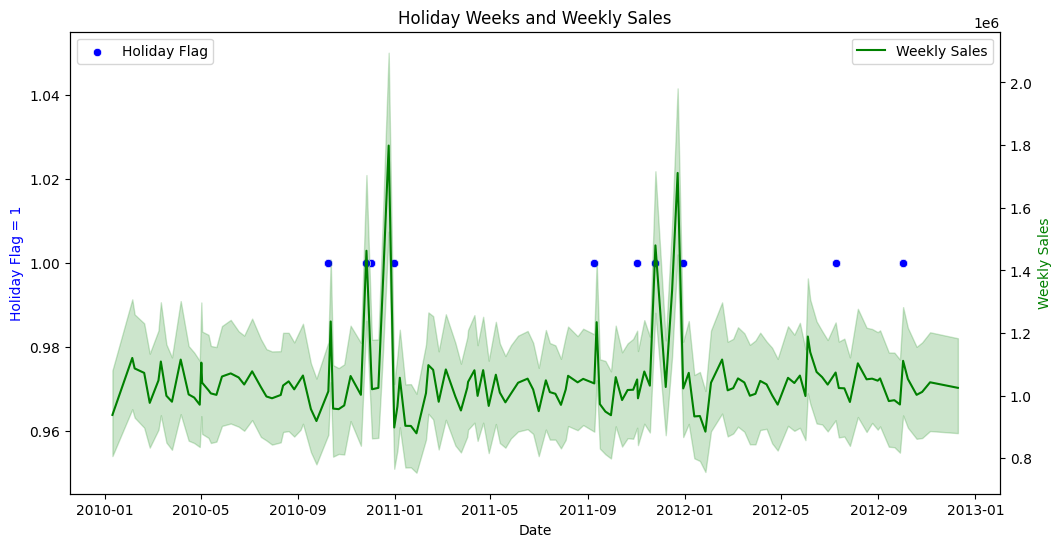

In [ ]:
# The weekly sales show a seasonal trend, when holiday are there.
# Filter only holiday weeks
holiday_weeks = df[df['Holiday_Flag'] == 1]

# Create a figure and axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot scatter plot for holiday flag
sns.scatterplot(x=holiday_weeks.index, y=holiday_weeks['Holiday_Flag'], color='blue', label='Holiday Flag', ax=ax1)

# Create a secondary y-axis
ax2 = ax1.twinx()

# Plot line plot for weekly sales on the secondary y-axis
sns.lineplot(x=df.index, y=df['Weekly_Sales'], color='green', label='Weekly Sales', ax=ax2)

# Set titles and labels
ax1.set_title('Holiday Weeks and Weekly Sales')
ax1.set_xlabel('Date')
ax1.set_ylabel('Holiday Flag = 1', color='blue')
ax2.set_ylabel('Weekly Sales', color='green')

# Display legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

The weekly sales show a seasonal trend, when holiday are there.

2. Use predictive modeling techniques to forecast the sales for each store for the next 12
weeks.

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Walmart DataSet.csv')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.index = df['Date']
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,,
2010-02-05,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
2010-02-12,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2010-02-19,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
2010-02-26,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
2010-03-05,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:

df1 = pd.DataFrame()
df1 = df.copy()
df1['Month'] = df.Date.dt.month
df1['Year'] = df.Date.dt.year
df1['Day'] = df.Date.dt.day
df1['day_name'] = df.Date.dt.day_name()
df1['week'] = df.Date.dt.isocalendar().week
df1.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Day,day_name,week
Date,,,,,,,,,,,,,
2010-02-05,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,5,Friday,5
2010-02-12,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,12,Friday,6
2010-02-19,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,19,Friday,7
2010-02-26,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,26,Friday,8
2010-03-05,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,5,Friday,9


In [ ]:
Stores = {}
for i in range(1,len(df.Store.unique())+1):
    Stores[i] = df1[df1['Store'] == i]


In [ ]:
Stores[1]

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Day,day_name,week
Date,,,,,,,,,,,,,
2010-02-05,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,5,Friday,5
2010-02-12,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,12,Friday,6
2010-02-19,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,19,Friday,7
2010-02-26,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,26,Friday,8
2010-03-05,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,5,Friday,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-09-28,1,2012-09-28,1437059.26,0,76.08,3.666,222.981658,6.908,9,2012,28,Friday,39
2012-10-05,1,2012-10-05,1670785.97,0,68.55,3.617,223.181477,6.573,10,2012,5,Friday,40
2012-10-12,1,2012-10-12,1573072.81,0,62.99,3.601,223.381296,6.573,10,2012,12,Friday,41


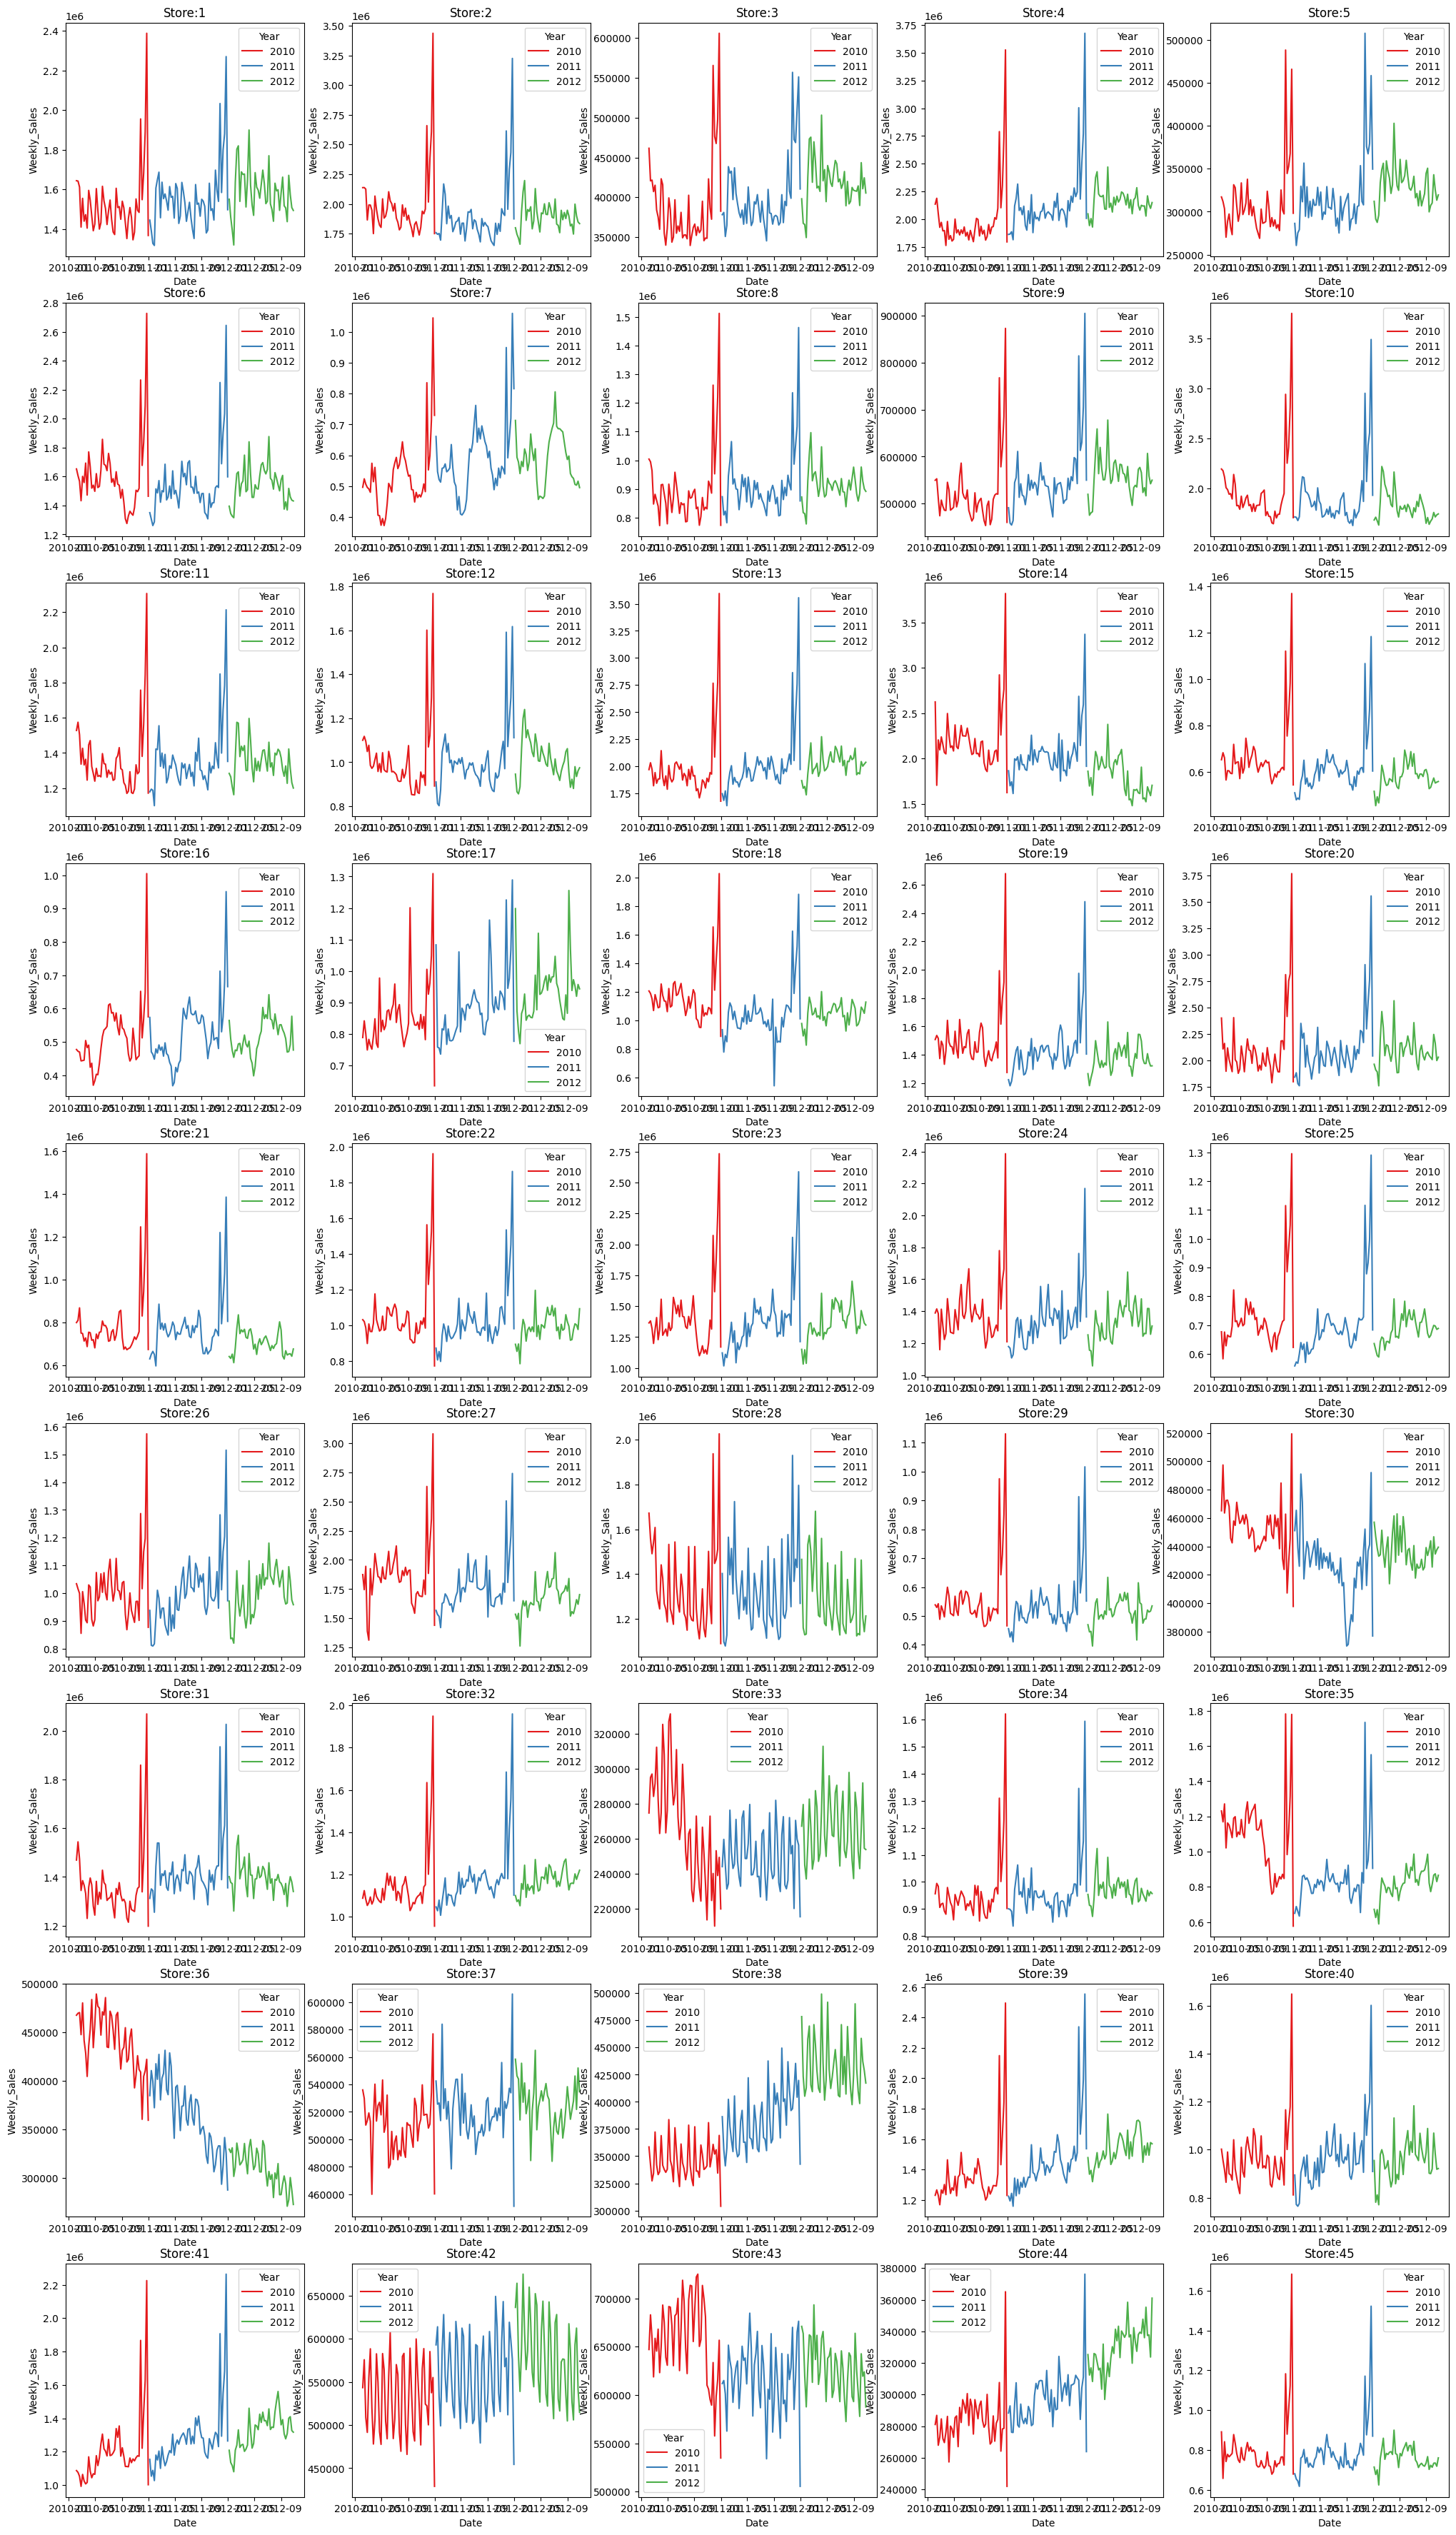

In [ ]:
plt.subplots(9,5, figsize=(25,45))
for i in range (1,46):
    plt.subplot(9,5,i)
    sns.lineplot(x='Date', y='Weekly_Sales', data=Stores[i], hue='Year',palette='Set1')
    plt.title(f'Store:{i}')

Time series and Forecasting

In [ ]:
df1 = Stores[1]
df1 = df1.loc[:,['Date', 'Weekly_Sales']]
df1.index = df1['Date']
df1.drop(['Date'], axis=1, inplace=True)
df1.head()

,Weekly_Sales
Date,
2010-02-05,1643690.90
2010-02-12,1641957.44
2010-02-19,1611968.17
2010-02-26,1409727.59
2010-03-05,1554806.68


In [ ]:
df1.shape

(143, 1)

<Axes: xlabel='Date'>

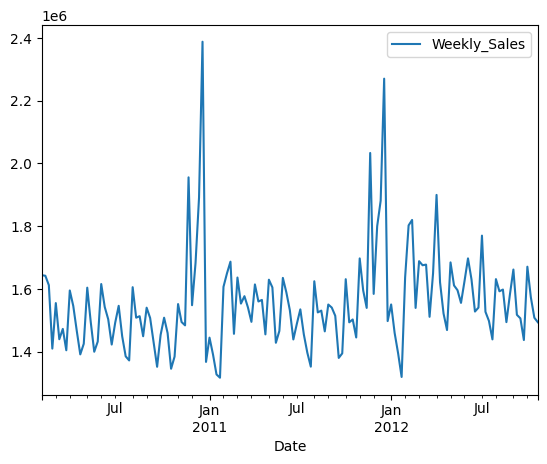

In [ ]:
df1.plot()

Stationarity test

In [ ]:
from statsmodels.tsa.stattools import adfuller
# p-value>0.05 --> not stationary --> Null Hyp
# p-value<0.05 --> stationary --> Alt Hyp
result = adfuller(df1['Weekly_Sales'])
p_value = result[1]
print(p_value)
if p_value<0.05:
    print('Stationary')
else:
    print('Not stationary')

1.3877788330759434e-05
Stationary


In [ ]:
# KPSS test( Kwiatkowski–Phillips–Schmidt–Shin test)
from statsmodels.tsa.stattools import kpss
stats,p,lags,critical = kpss(df1['Weekly_Sales'])
if p>0.05:
    print('Stationary')
else:
    print('Not stationary')
print(p)

Not stationary
0.047095888148842614


Seasionality of this data is one year, so we take window 52 (52 weeks per year).

In [ ]:
rolling_mean = df1.rolling(window=52).mean()
rolling_mean

,Weekly_Sales
Date,
2010-02-05,NaN
2010-02-12,NaN
2010-02-19,NaN
2010-02-26,NaN
2010-03-05,NaN
...,...
2012-09-28,1.613969e+06
2012-10-05,1.614734e+06
2012-10-12,1.616264e+06


Removing the trend from the timestamp if trend is present¶

In [ ]:
rolling_mean_detrended = df1-rolling_mean
rolling_mean_detrended

,Weekly_Sales
Date,
2010-02-05,NaN
2010-02-12,NaN
2010-02-19,NaN
2010-02-26,NaN
2010-03-05,NaN
...,...
2012-09-28,-176909.317308
2012-10-05,56052.084615
2012-10-12,-43190.823077


<Axes: xlabel='Date'>

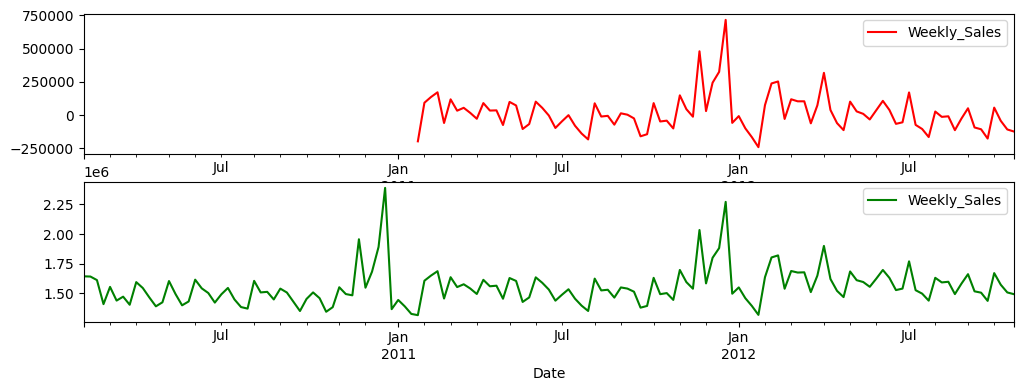

In [ ]:
ax1 = plt.subplot(211)
rolling_mean_detrended.plot(figsize=(12,4),color='red',ax=ax1)
ax2 = plt.subplot(212)
df1.plot(figsize=(12,4),color='green',ax=ax2)

Removing seasonality

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decompose_result = seasonal_decompose(rolling_mean_detrended.dropna(), period=25)

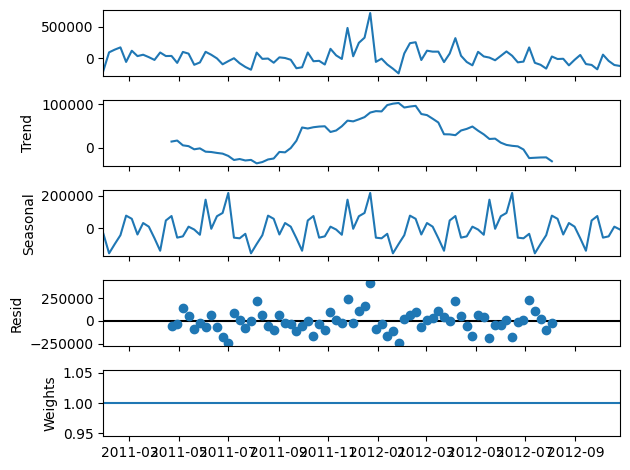

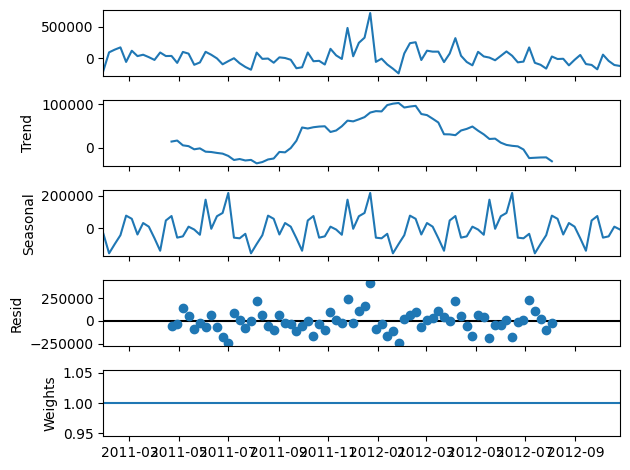

In [ ]:
decompose_result.plot(weights=True)

In [ ]:
# removing seasionality
rolling_mean_decomposed_diff = rolling_mean_detrended - rolling_mean_detrended.shift()
rolling_mean_decomposed_diff

,Weekly_Sales
Date,
2010-02-05,NaN
2010-02-12,NaN
2010-02-19,NaN
2010-02-26,NaN
2010-03-05,NaN
...,...
2012-09-28,-69884.058269
2012-10-05,232961.401923
2012-10-12,-99242.907692


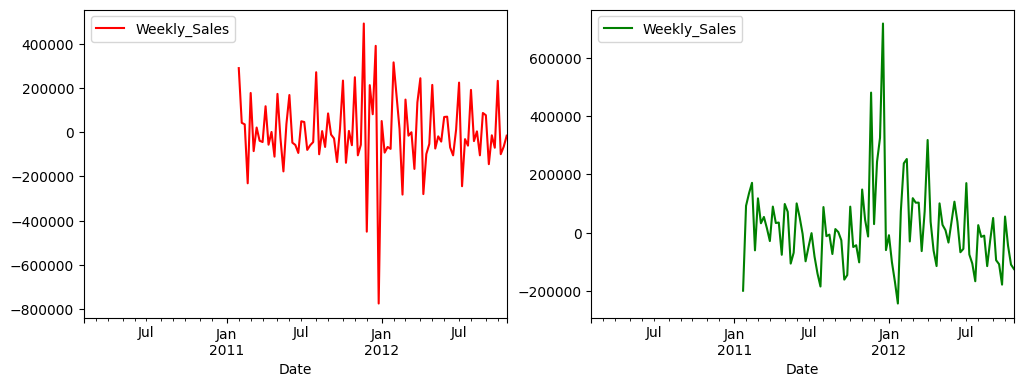

In [ ]:
ax1=plt.subplot(121)
rolling_mean_decomposed_diff.plot(figsize=(12,4),color='red',ax=ax1)
ax2=plt.subplot(122)
rolling_mean_detrended.plot(figsize=(12,4),color='green',ax=ax2)
plt.show()

In [ ]:
rolling_mean_decomposed_diff.dropna(inplace=True)
rolling_mean_decomposed_diff

,Weekly_Sales
Date,
2011-02-04,290442.987692
2011-02-11,42838.090577
2011-02-18,35787.953654
2011-02-25,-230947.744038
2011-03-04,177896.654423
...,...
2012-09-28,-69884.058269
2012-10-05,232961.401923
2012-10-12,-99242.907692


In [ ]:
final = adfuller(rolling_mean_decomposed_diff['Weekly_Sales'])
final[1]

3.257853293563666e-07

Visualize ACF and PACF to choose the Times seris model

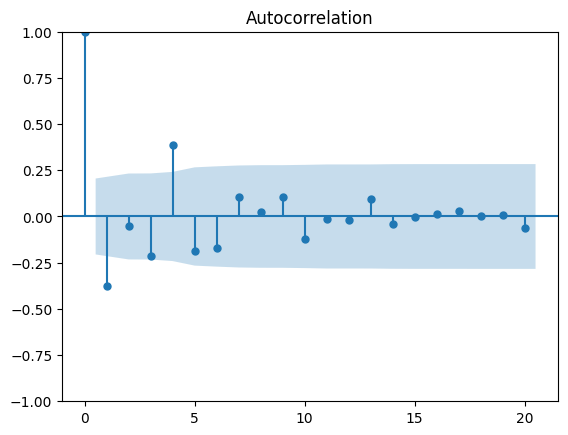

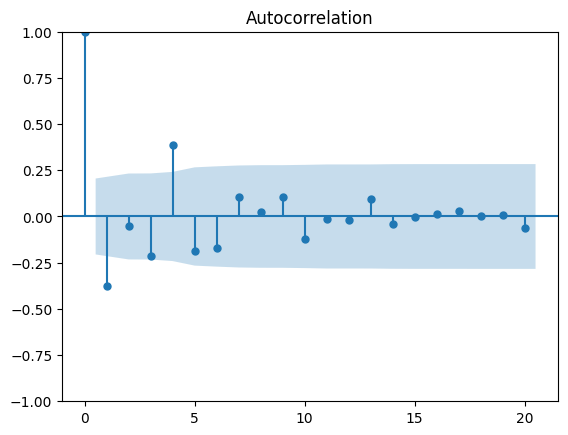

In [ ]:
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(rolling_mean_decomposed_diff['Weekly_Sales'])

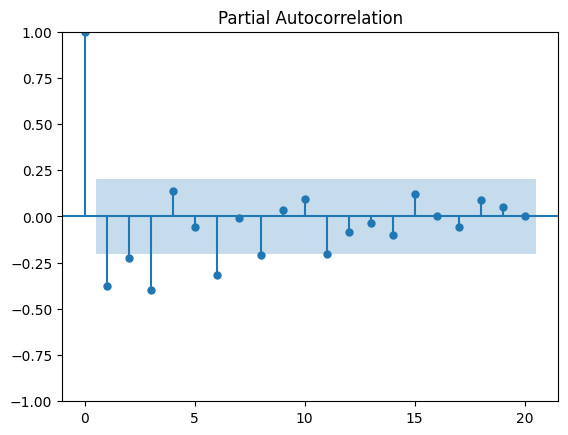

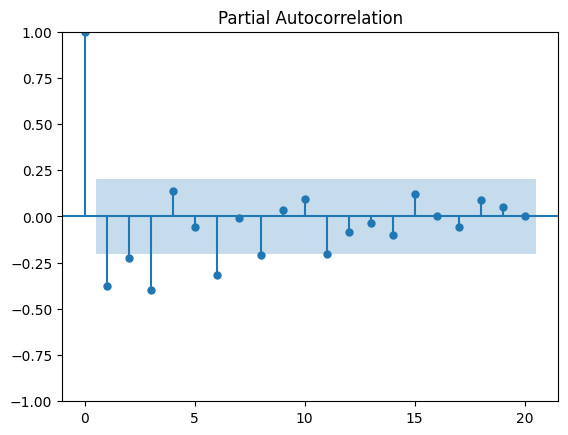

In [ ]:
plot_pacf(rolling_mean_decomposed_diff['Weekly_Sales'])

Choosing the best model using autoarima

In [ ]:
! pip install pmdarima
from pmdarima import auto_arima
order = auto_arima(rolling_mean_decomposed_diff['Weekly_Sales'],trace=True)
order.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=2428.230, Time=0.37 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=2454.958, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=2442.923, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=2426.044, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2452.960, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=2426.893, Time=0.13 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=2426.900, Time=0.14 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=2428.257, Time=0.30 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2422.325, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2421.076, Time=0.15 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2440.908, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.34 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=2424.524, Time=0.29 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=2423.465, Time=0.10 sec
 ARIMA(2,0,0)(0,0,0)[0]             : 

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   91
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -1207.538
Date:                Sun, 18 Feb 2024   AIC                           2421.076
Time:                        14:45:16   BIC                           2428.608
Sample:                    02-04-2011   HQIC                          2424.115
                         - 10-26-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2370      0.116      2.050      0.040       0.010       0.464
ma.L1         -0.9361      0.054    -17.315      0.000      -1.042      -0.830
sigma2      2.002e+10   7.21e-13   2.78e+22      0.000       2e+10       2e+10
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                83.49
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.21   Skew:                             1.39
Prob(H) (two-sided):                  0.61   Kurtosis:                         6.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.98e+37. Standard errors may be unstable.
"""

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

train = rolling_mean_decomposed_diff.iloc[:73]['Weekly_Sales']
test = rolling_mean_decomposed_diff.iloc[73:]['Weekly_Sales']
# ARIMA ---> AR + MA +I ---> ARIMA--> AR=1 , I=0 , MA=1
model = ARIMA(train, order=(1,0,1))
model_fit = model.fit() # training
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           Weekly_Sales   No. Observations:                   73
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -972.872
Date:                Sun, 18 Feb 2024   AIC                           1953.744
Time:                        14:45:17   BIC                           1962.906
Sample:                    02-04-2011   HQIC                          1957.395
                         - 06-22-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1802.9196   1363.342      1.322      0.186    -869.181    4475.021
ar.L1          0.2757      0.095      2.912      0.004       0.090       0.461
ma.L1         -0.9892      0.131     -7.572      0.000      -1.245      -0.733
sigma2      2.317e+10   4.19e-05   5.53e+14      0.000    2.32e+10    2.32e+10
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                55.00
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.84   Skew:                             1.34
Prob(H) (two-sided):                  0.14   Kurtosis:                         6.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.21e+30. Standard errors may be unstable.
"""

In [ ]:

rolling_mean_decomposed_diff['Predict'] = model_fit.predict(start= len(train),end=len(train)+len(test)- 1, dynamic=True)
rolling_mean_decomposed_diff['Predict']

Date
2011-02-04            NaN
2011-02-11            NaN
2011-02-18            NaN
2011-02-25            NaN
2011-03-04            NaN
                 ...     
2012-09-28    1802.925716
2012-10-05    1802.921273
2012-10-12    1802.920048
2012-10-19    1802.919710
2012-10-26    1802.919617
Name: Predict, Length: 91, dtype: float64

<Axes: xlabel='Date'>

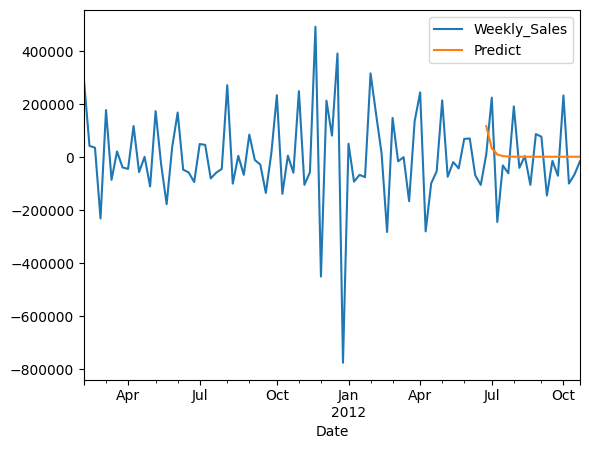

In [ ]:
rolling_mean_decomposed_diff[['Weekly_Sales','Predict']].plot()

ARIMA model is not worling well, so we are going to use SARIMAX model on the same order

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX,SARIMAXResults

model=SARIMAX(train,order=(1,0,1),seasonal_order=(1,0,1,52),enforce_stationarity=False)
model=model.fit()

<Axes: xlabel='Date'>

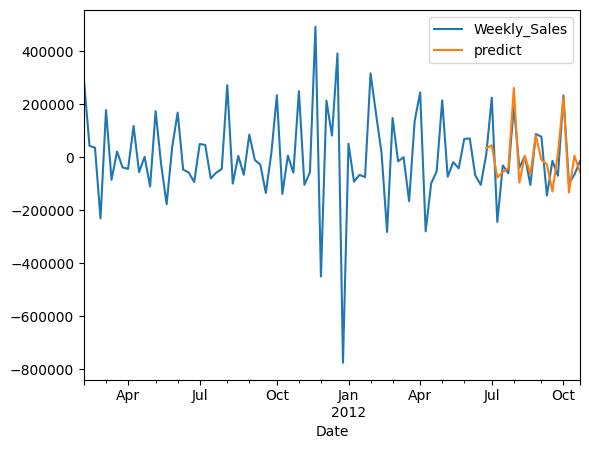

In [ ]:
rolling_mean_decomposed_diff['predict'] = model.predict(start= len(train) ,
                                                       end=len(train)+len(test)- 1,
                                                       dynamic=True)
rolling_mean_decomposed_diff[['Weekly_Sales','predict']].plot()

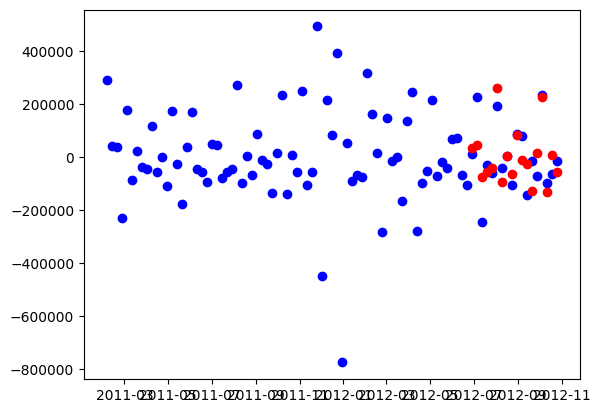

In [ ]:
plt.plot(rolling_mean_decomposed_diff['Weekly_Sales'],'bo')
plt.plot(rolling_mean_decomposed_diff['predict'],'ro')

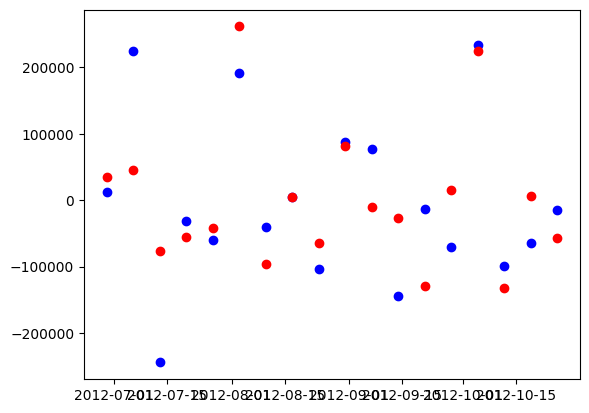

In [ ]:
plt.plot(test,'bo')
plt.plot(rolling_mean_decomposed_diff['predict'],'ro')

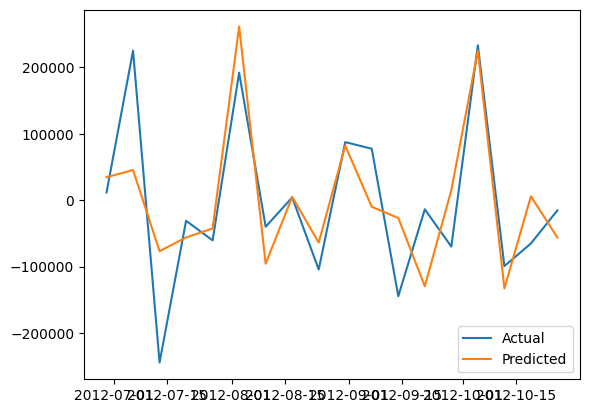

In [ ]:
plt.plot(test, label='Actual')
plt.plot(rolling_mean_decomposed_diff['predict'], label='Predicted')
plt.legend()

We can check the model performance from the above graph, it predicted nearly possible values.

In [ ]:
rolling_mean_decomposed_diff.drop('Predict',axis=1, inplace=True)

<Axes: xlabel='Date'>

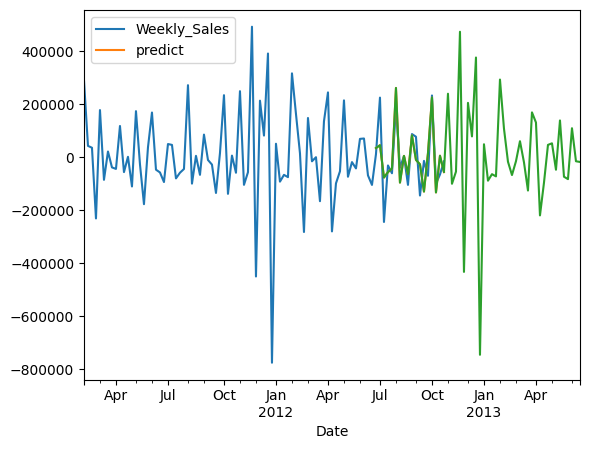

In [ ]:
#predicting the projections for the next 1 year

forecast = model.forecast(steps=52)
rolling_mean_decomposed_diff.plot()
forecast.plot()

From the above graph we can conclude that this model predicted the sales approximatly 90%

Checking the metrics

In [ ]:
from sklearn.metrics import mean_absolute_error

y_train=train
y_true = test
y_pred = rolling_mean_decomposed_diff['predict'].dropna()

def mean_absolute_scaled_error(y_true, y_pred, y_train):
    e_t = y_true - y_pred
    scale = mean_absolute_error(y_train[1:], y_train[:-1])
    return np.mean(np.abs(e_t / scale))

print('Mean absolute scaled error of this SARIMAX model is ',mean_absolute_scaled_error(y_true, y_pred, y_train))

Mean absolute scaled error of this SARIMAX model is  0.3064546755563048


Lets check this model with another store

In [ ]:
results = {}
for i in np.random.randint(1,45,5):
    store = Stores[i]
    store = store.loc[:,['Date','Weekly_Sales']]
    store.index = store['Date']
    store.drop(['Date'],axis=1,inplace=True)
    model=SARIMAX(store,order=(1,0,1),seasonal_order=(1,0,1,52),enforce_stationarity=False)
    model=model.fit()
    predict = model.predict(start= len(store) ,end=len(store)+12, dynamic=True)
    results[i] = predict

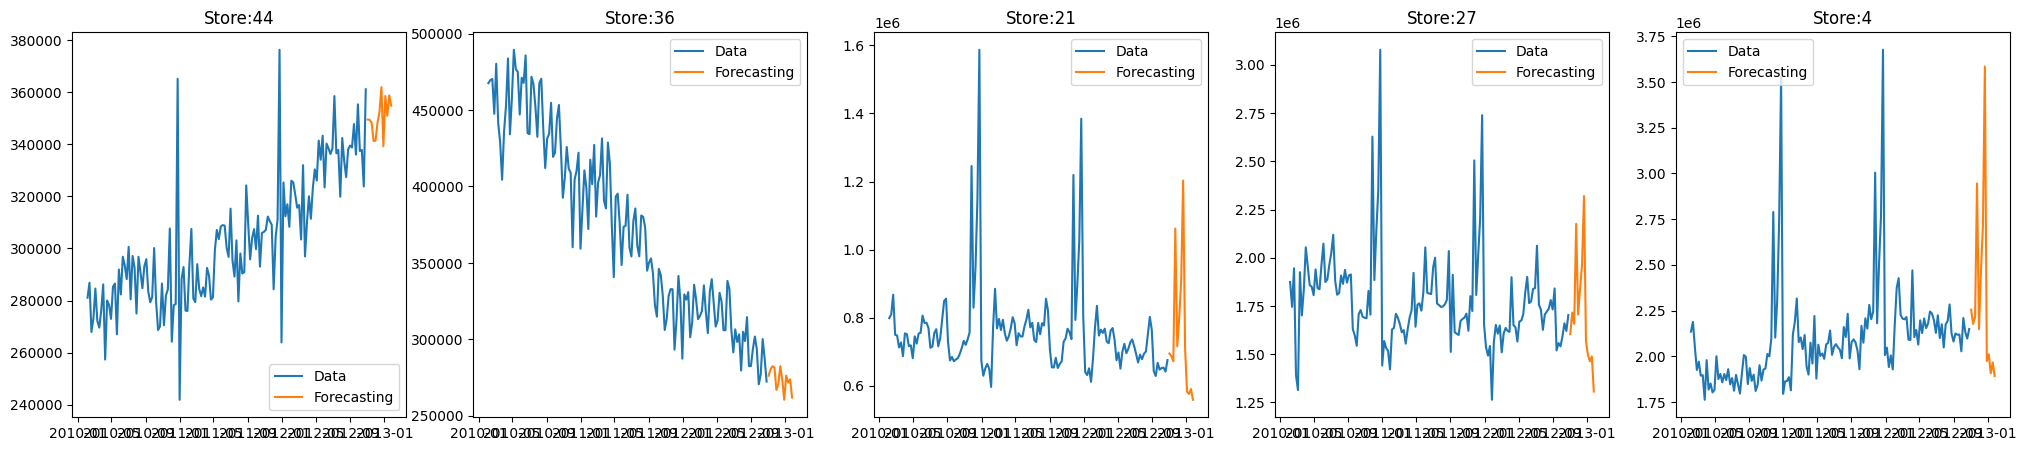

In [ ]:
plt.subplots(1,5, figsize=(25,5))
i = 1
for value in results.keys():
    store=Stores[value]
    store = store.loc[:,['Date','Weekly_Sales']]
    store.index = store['Date']
    store.drop(['Date'],axis=1, inplace=True)
    result = results[value]
    plt.subplot(1,5,i)
    plt.plot(store, label='Data')
    plt.plot(result, label='Forecasting')
    plt.title(f'Store:{value}')
    plt.legend()
    i += 1

From the above graph we can see that this model forecasted the future sales approximately as same as the data set regarding the seasionality

Lets forecast next 12 weeks of sales for each stores

In [ ]:
predictions = {}
for i in range(1,len(df.Store.unique())+1):
    store = Stores[i]
    store = store.loc[:,['Date','Weekly_Sales']]
    store.index = store['Date']
    store.drop(['Date'],axis=1,inplace=True)
    model=SARIMAX(store,order=(1,0,1),seasonal_order=(1,0,1,52),enforce_stationarity=False)
    model=model.fit()
    predict = model.predict(start= len(store) ,end=len(store)+12, dynamic=True)
    predictions[i] = predict

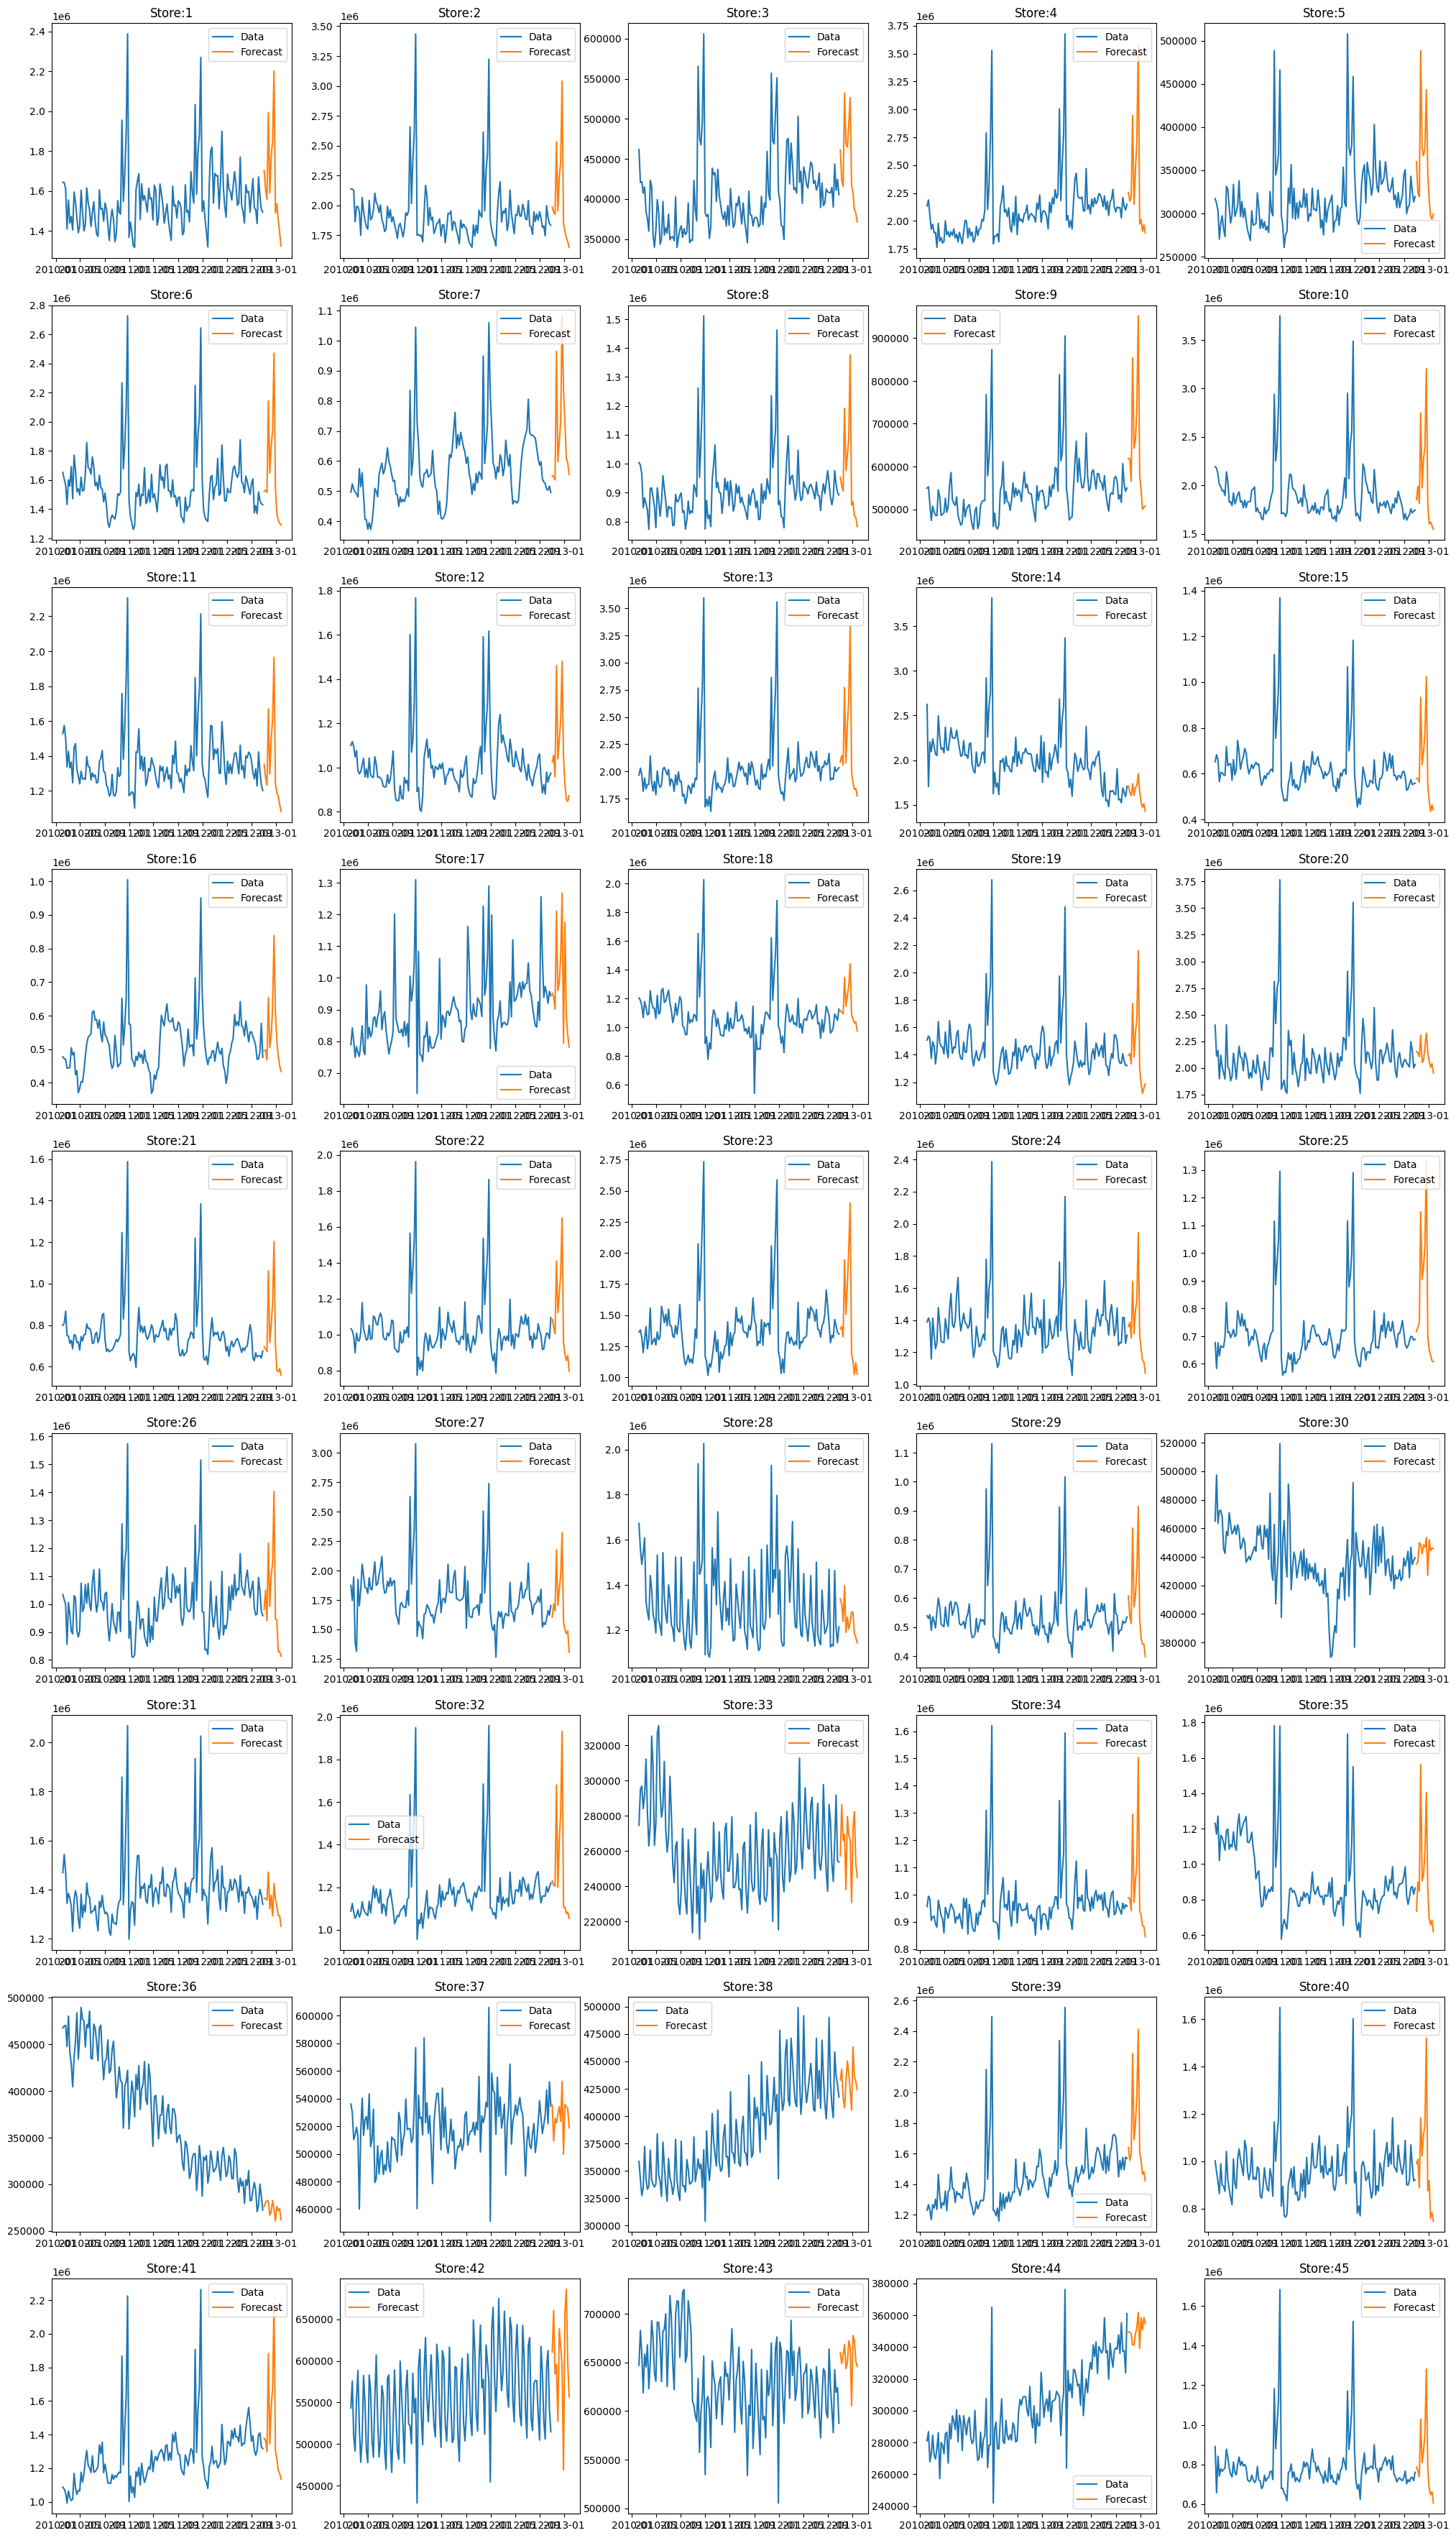

In [ ]:
plt.subplots(9,5, figsize=(25,45))
for i in range (1,46):
    store=Stores[i]
    store = store.loc[:,['Date','Weekly_Sales']]
    store.index = store['Date']
    store.drop(['Date'],axis=1, inplace=True)
    predict = predictions[i]
    plt.subplot(9,5,i)
    plt.plot(store,label='Data')
    plt.plot(predict,label='Forecast')
    plt.title(f'Store:{i}')
    plt.legend()

Conclusion
From the above graph we can see that the Stores 14,20,28,30,31,37,44 are having poor forecasting. Overall 38 stores out of 45 are forecasted well successfully using the SARIMAX model with the order = (1,0,1) and seasonal order = (1,0,1,52). The Mean Absolute Scaled error of this model is 0.3.¶